# PsAID Hierarchical Clustering

## Comments for Change

TO DO: 
- Implement the cophenetic correlation of the dendrogram. To check if the dendrogram embedding fits the data. [CHECK]
  
CONSIDERATIONS: 
- Average linkage makes probably more sense since our data is not normally distributed. Wards linkage merges clusters based on variance. Check if this is true. However when you look at the clusters sizes it does not make much sense, since you see there is big imablance among cluster sizes (single datapoint clusters).




## Initialization

In [1]:
## Set up
## Import Packages
import warnings
import os

import pandas as pd
import numpy as np
import re # Regular Expressions

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, fowlkes_mallows_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from scipy import stats
from scipy.stats import iqr
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment


import seaborn as sns
import matplotlib.pyplot as plt

# Suppress Future Warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import contextlib #Suppress prints during when executing functions
import io

# Specify Paths
figure_storage = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Hierarchical Clustering/Figures"
data_storage = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Hierarchical Clustering"


RandomSeed = 42

In [2]:
## Import Dataset
psaid12 = pd.read_csv('/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection/PsAID_Preprocessed.csv') # Import dataset
psaid12.head() # Check data

## Define Varlists
columns_gp = [i for i in psaid12.columns if re.match(r'^gp\d{2}$',i)]
#psaid12.head() # Check data

In [3]:
## Create Dictionaries & Lists

domains_dict = {
    'gp01': 'Pain',
    'gp02': 'Fatigue',
    'gp03': 'Skin',
    'gp04': 'Work-recreational activities',
    'gp05': 'Bodily functioning',
    'gp06': 'Discomfort',
    'gp07': 'Sleep',
    'gp08': 'Coping',
    'gp09': 'Anxiety',
    'gp10': 'Shame',
    'gp11': 'Social activities',
    'gp12': 'Depression'
}

# # Create Codebook
# print(f' The imported PsAID dataset contains {len(psaid12)} datapoints')
# psaid_codebook = pd.DataFrame({
#     'Variable' : psaid12.columns.tolist(),
#     'Data_type' : psaid12.dtypes.tolist(),
#     'Description' : ['Participant', 'Moment of measurement', 'Date of completion', 'Q1 pain', 'Q2 fatigue', 'Q3 skin', 'Q4 work-recreational activities', 'Q5 bodily functioning', 'Q6 discomfort', 'Q7 sleep', 'Q8 coping', 'Q9 anxiety','Q10 shame', 'Q11 social activities', 'Q12 depression', 'PsAID12 Total score'],
#     'Exact Question': [ '-',
#                         '-',
#                         '-',
#                         'Kies het getal dat het beste de pijn beschrijft die u voelde als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de mate van vermoeidheid beschrijft die u voelde als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de huidproblemen (inclusief jeuk) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de moeilijkheden beschrijft die u ondervond om volwaardig deel te nemen aan werk- en/of vrije tijdsactiviteiten als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de moeilijkheden met dagelijkse lichamelijke activiteiten beschrijft die u ondervond als gevolg van van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste het gevoel van ongemak en ergernis bij alledaagse activiteiten beschrijft als gevolg van uw artritis psoriatica in de afgelopen week.',
#                         'Kies het getal dat het beste de slaapproblemen (bijv. uw nachtrust) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kijkend naar uw artritis psoriatica in het algemeen, hoe goed kon u met uw ziekte omgaan gedurende de afgelopen week?',
#                         'Kies het getal dat het beste de mate van angst, bezorgdheid en onzekerheid (bijv. over de toekomst, behandelingen, angst voor eenzaamheid) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Uw artritis psoriatica in het algemeen genomen, kies het getal dat het beste de mate van schaamte beschrijft die u ondervond als gevolg van de zichtbaarheid van uw ziekte gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de problemen beschrijft die u had om volledig aan sociale activiteiten deel te nemen (inclusief relaties met familie en vrienden) als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de mate van depressie en/of neerslachtigheid beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         '-']
# })

#psaid_codebook 

## Determine Configurations

In [4]:
configs = []
def HAC_clustering(configs, data, link, distance_metric, thresholds):
    if distance_metric == 'manhattan':
        linkage_matrix_distance = 'cityblock'
        distance_suffix = 'L1'
    else:
        linkage_matrix_distance = distance_metric
        distance_suffix = ''
    print(linkage_matrix_distance)
    
    # Run agglomeration algorithm
    HAC_ward = AgglomerativeClustering(n_clusters=10, linkage = link, metric = linkage_matrix_distance).fit(data[columns_gp])
    
    # Create linkage matrix
    linkage_matrix = linkage(data[columns_gp], method=link, metric = linkage_matrix_distance)

    #Compute cophenetic distances and correlation
    # -----------------------
    # The cophenetic correlation coefficient measures how faithfully the 
    # hierarchical clustering dendrogram preserves the pairwise distances 
    # between the original data points. 
    # 
    # - Values close to 1 indicate that the dendrogram is a very good representation 
    #   of the original distances.
    # - Values around 0.7–0.8 are considered good, while 0.6–0.7 is moderate.
    # - Values below 0.6 suggest the dendrogram may distort the true distances.
    #
    # In practice, a moderate correlation (e.g., ~0.68) indicates that the 
    # dendrogram roughly reflects the structure in the data, and cluster 
    # assignments can still be meaningfully interpreted if they are stable 
    # across bootstraps.
    dist = pdist(data[columns_gp], metric = linkage_matrix_distance) # Pairwise Distances
    coph_corr, coph_dists = cophenet(linkage_matrix, dist) # Cophenetic Distances & Correlation
    
    # Plot Dendrogram
    plt.figure(figsize=(10,7))
    dendrogram(linkage_matrix, labels=data[columns_gp].index, leaf_rotation=90, leaf_font_size=8)
    plt.title(f'Hierarchical Clustering Dendrogram, link {link}')
    plt.xlabel("Sample Index")
    plt.ylabel(f'Distance {distance_metric}')
    for threshold in thresholds:
        plt.axhline(y=threshold)
    plt.figtext( 0.05, -0.05, f"Cophenetic correlation: {coph_corr}",
       # ha="center", fontsize=10
    )
    plt.tight_layout()
    plt.show()
    
    # Assign Clusters
    clusterIDs = pd.DataFrame()
    for threshold in thresholds:
        cluster_assignment = fcluster(linkage_matrix, t=threshold, criterion = 'distance')
        n_clusters = len(np.unique(cluster_assignment))
        clusterIDs[f'clusterID_{link}{distance_suffix}_k{n_clusters}'] = cluster_assignment

        # Store configurations in dictionary
        configs_dict = {
            'cluster_name': f'clusterID_{link}{distance_suffix}_k{n_clusters}',
            'link': link,
            'distance_metric': distance_metric,
            'n_clusters': n_clusters,
            'cophenetic corr': coph_corr
        }

        configs.append(configs_dict)
    

    return configs, clusterIDs

### Ward Linkage

euclidean


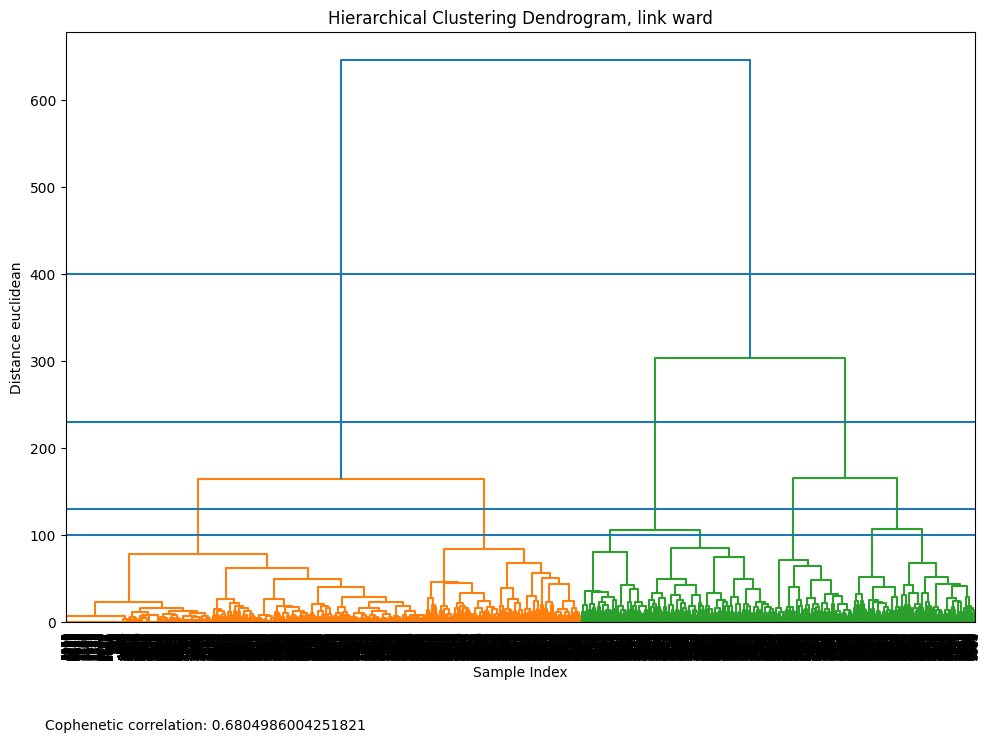

In [5]:
link = 'ward'
distance_metric = 'euclidean' # Ward can only be performed with euclidean distance
#thresholds = [400, 200, 150, 100] #Originally
thresholds= [400, 230, 130, 100] # New 

# Compute Clusters|}
configs, clusterIDs_ward= HAC_clustering(configs, psaid12[columns_gp], link, distance_metric, thresholds)

# Add clusters to dataset
psaid12 = pd.concat([psaid12.copy(), clusterIDs_ward], axis=1)

### Average Linkage

#### Euclidean Distance

euclidean


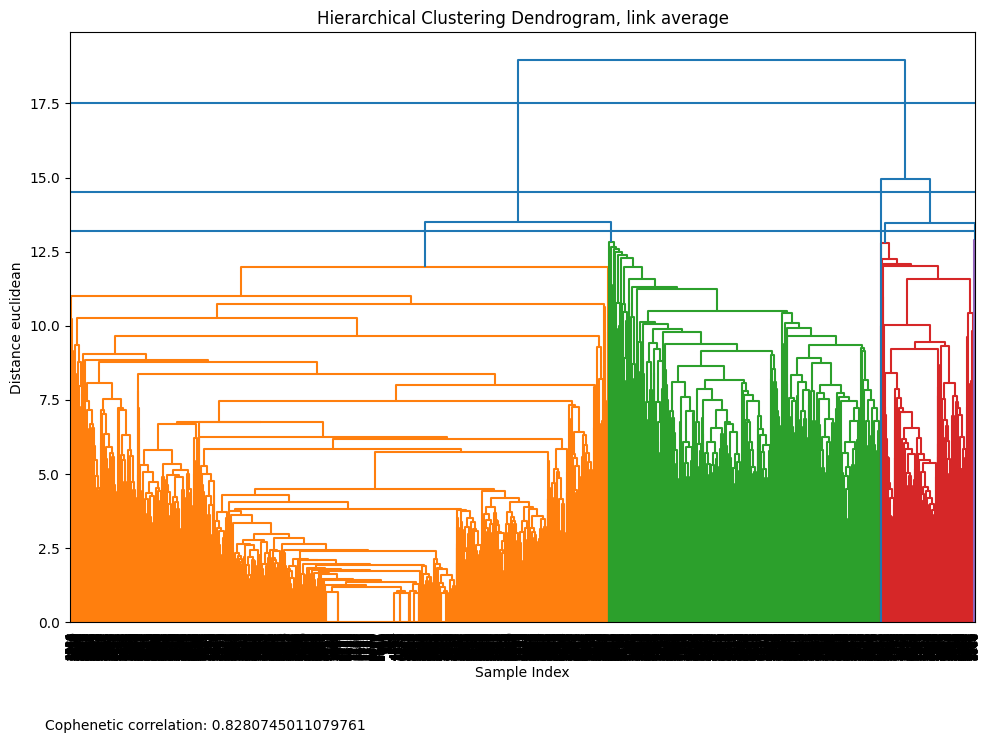

In [6]:
link = 'average'
distance_metric = 'euclidean' # = L2
thresholds = [17.5, 14.5, 13.2]

# Compute Clusters
configs, clusterIDs_avg = HAC_clustering(configs, psaid12[columns_gp], link, distance_metric, thresholds)
clusterIDs_avg

# Add clusters to dataset
psaid12 = pd.concat([psaid12.copy(), clusterIDs_avg], axis=1)

#### Manhattan Distance

cityblock


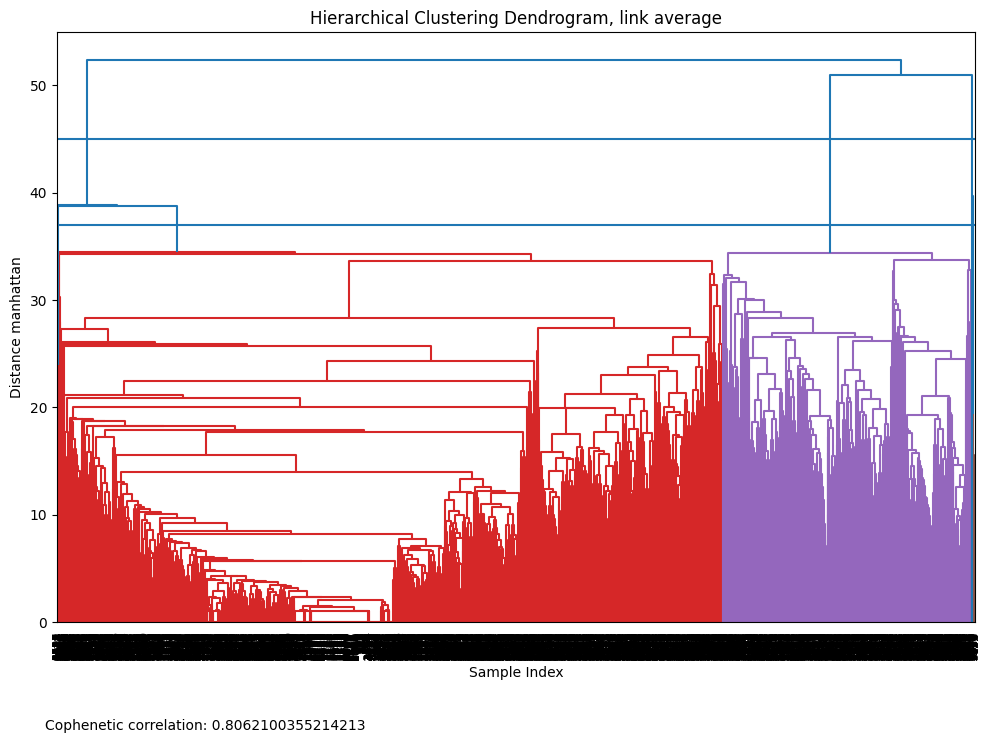

In [7]:
link = 'average'
distance_metric = 'manhattan' # Manhattan == L1 == CityBlock
thresholds = [45, 37]

# Compute Clusters
configs, clusterIDs_avg_L1 = HAC_clustering(configs, psaid12[columns_gp], link, distance_metric, thresholds)
clusterIDs_avg_L1

# Add clusters to dataset
psaid12 = pd.concat([psaid12.copy(), clusterIDs_avg_L1], axis=1)

### Complete Linkage

#### Euclidean Distance

euclidean


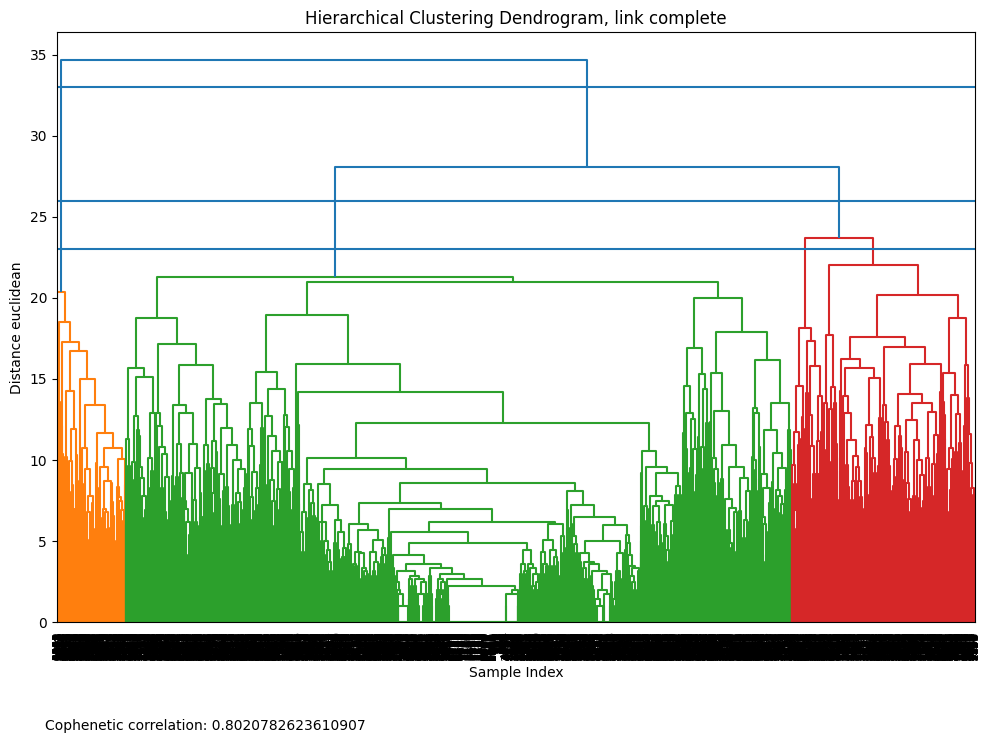

In [8]:
link = 'complete'
distance_metric = 'euclidean' # = L2
thresholds = [33, 26, 23]

# Compute Clusters
configs, clusterIDs_compl = HAC_clustering(configs, psaid12[columns_gp], link, distance_metric, thresholds)
clusterIDs_compl

# Add clusters to dataset
psaid12 = pd.concat([psaid12.copy(), clusterIDs_compl], axis=1)

#### Complete Linkage

cityblock


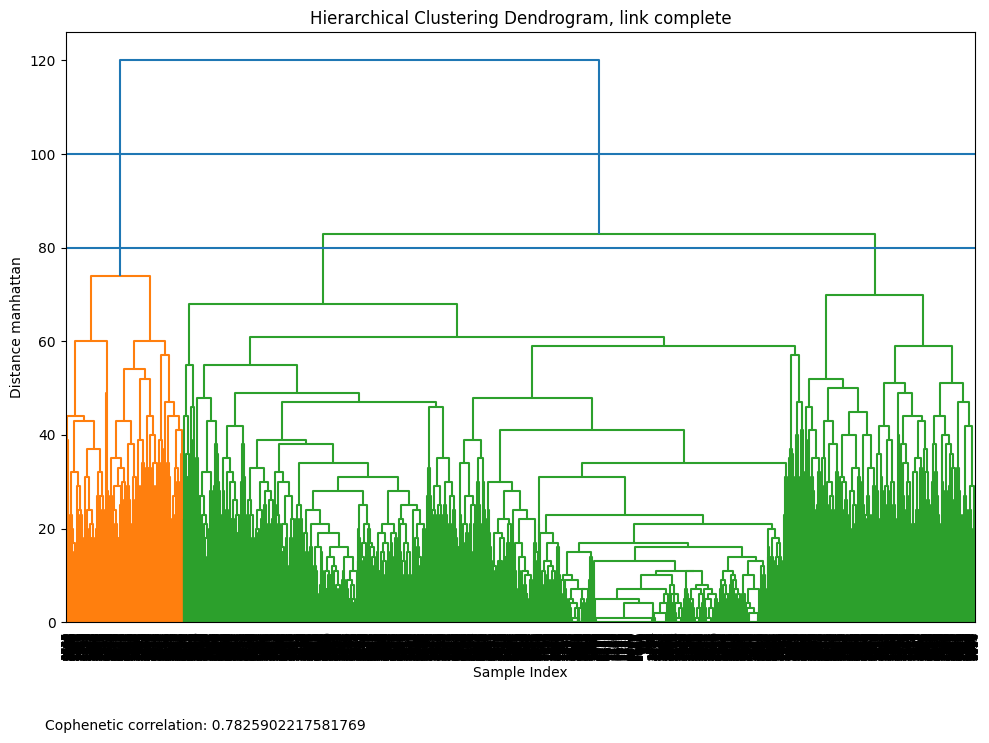

In [9]:
link = 'complete'
distance_metric = 'manhattan' # = L2
thresholds = [100, 80]

# Compute Clusters
configs, clusterIDs_compl = HAC_clustering(configs, psaid12[columns_gp], link, distance_metric, thresholds)
clusterIDs_compl

# Add clusters to dataset
psaid12 = pd.concat([psaid12.copy(), clusterIDs_compl], axis=1)

In [10]:
configs

[{'cluster_name': 'clusterID_ward_k2',
  'link': 'ward',
  'distance_metric': 'euclidean',
  'n_clusters': 2,
  'cophenetic corr': 0.6804986004251821},
 {'cluster_name': 'clusterID_ward_k3',
  'link': 'ward',
  'distance_metric': 'euclidean',
  'n_clusters': 3,
  'cophenetic corr': 0.6804986004251821},
 {'cluster_name': 'clusterID_ward_k5',
  'link': 'ward',
  'distance_metric': 'euclidean',
  'n_clusters': 5,
  'cophenetic corr': 0.6804986004251821},
 {'cluster_name': 'clusterID_ward_k7',
  'link': 'ward',
  'distance_metric': 'euclidean',
  'n_clusters': 7,
  'cophenetic corr': 0.6804986004251821},
 {'cluster_name': 'clusterID_average_k2',
  'link': 'average',
  'distance_metric': 'euclidean',
  'n_clusters': 2,
  'cophenetic corr': 0.8280745011079761},
 {'cluster_name': 'clusterID_average_k3',
  'link': 'average',
  'distance_metric': 'euclidean',
  'n_clusters': 3,
  'cophenetic corr': 0.8280745011079761},
 {'cluster_name': 'clusterID_average_k5',
  'link': 'average',
  'distance_m

## Compute Internal Cluster Quality Scores

In [11]:
def compute_scores(configs, data, columns_gp, cluster_columns):
    results = []
    psaid = data[columns_gp]

    # Convert list of configs to a dict for fast lookup
    config_lookup = {conf['cluster_name']: conf for conf in configs}

    for cluster_assignment in cluster_columns:
        # Look up configurations
        config = config_lookup.get(cluster_assignment)
        print(config)
        link = config['link']
        distance = config['distance_metric']
        n_clusters = config['n_clusters']
        labels = data[cluster_assignment]

        #Compute Cluster Sizes
        cluster_size = labels.value_counts().sort_index().values # Array of cluster sizes

        #Compute Scores
        s_score = silhouette_score(psaid, labels, metric = distance)  # Can be computed for various distance metrics

        if distance == 'euclidean':
            ch_index = calinski_harabasz_score(psaid, labels)
            db_index = davies_bouldin_score(psaid, labels)
        else:
            ch_index = None
            db_index = None
            print(distance)
            print('Can not compute ch-index or db-index, since clusters are not computed with euclidean distance')
    
        # Append results
        results.append({
            'link': link,
            'distance metric': distance,
            'n_clusters': n_clusters,
            'silhouette_score': s_score,      # Higher values indicate better separation
            'calinski_harabasz': ch_index,    # Higher values indicate better separation. Within-cluster compactness vs the between-cluster dispersion.
            'davies_bouldin': db_index,       # Lower values indicate clusters are distinct. Measures average similarity between each cluster and its most similar other cluster
            'cluster_sizes': cluster_size
        })   

    # Convert results to a DataFrame and sort by silhouette score
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='n_clusters', ascending=True)

    return results_df

In [12]:
cluster_columns = [i for i in psaid12.columns if re.match(r'^clusterID_',i)]
print(cluster_columns)

results_df = compute_scores(configs, psaid12, columns_gp, cluster_columns)
results_df

['clusterID_ward_k2', 'clusterID_ward_k3', 'clusterID_ward_k5', 'clusterID_ward_k7', 'clusterID_average_k2', 'clusterID_average_k3', 'clusterID_average_k5', 'clusterID_averageL1_k3', 'clusterID_averageL1_k6', 'clusterID_complete_k2', 'clusterID_complete_k3', 'clusterID_complete_k4', 'clusterID_completeL1_k2', 'clusterID_completeL1_k3']
{'cluster_name': 'clusterID_ward_k2', 'link': 'ward', 'distance_metric': 'euclidean', 'n_clusters': 2, 'cophenetic corr': 0.6804986004251821}
{'cluster_name': 'clusterID_ward_k3', 'link': 'ward', 'distance_metric': 'euclidean', 'n_clusters': 3, 'cophenetic corr': 0.6804986004251821}
{'cluster_name': 'clusterID_ward_k5', 'link': 'ward', 'distance_metric': 'euclidean', 'n_clusters': 5, 'cophenetic corr': 0.6804986004251821}
{'cluster_name': 'clusterID_ward_k7', 'link': 'ward', 'distance_metric': 'euclidean', 'n_clusters': 7, 'cophenetic corr': 0.6804986004251821}
{'cluster_name': 'clusterID_average_k2', 'link': 'average', 'distance_metric': 'euclidean', 'n

,link,distance metric,n_clusters,silhouette_score,calinski_harabasz,davies_bouldin,cluster_sizes
0,ward,euclidean,2,0.427679,4742.537727,0.956601,"[2892, 2207]"
4,average,euclidean,2,0.432643,2300.500979,0.803599,"[4568, 531]"
9,complete,euclidean,2,0.423864,1742.292997,0.735594,"[383, 4716]"
12,complete,manhattan,2,0.480475,NaN,NaN,"[662, 4437]"
1,ward,euclidean,3,0.343272,3640.811016,1.422405,"[2892, 1088, 1119]"
5,average,euclidean,3,0.418416,1152.308215,0.689726,"[4568, 530, 1]"
7,average,manhattan,3,0.483664,NaN,NaN,"[3700, 1381, 18]"
10,complete,euclidean,3,0.386928,2976.328329,1.265084,"[383, 3697, 1019]"
13,complete,manhattan,3,0.401938,NaN,NaN,"[662, 3485, 952]"
11,complete,euclidean,4,0.361846,2067.363411,1.878395,"[383, 3697, 179, 840]"


## Evaluate Clustering Quality

#### Cluster Size & Variance

In [13]:
desc = [] 

def cluster_size_spread(data, cluster_assignment, byvar, desc):
    """

    """
    cluster_centers_mean = pd.DataFrame()
    cluster_size = pd.DataFrame()
    cluster_spread = pd.DataFrame()

    cluster_size = pd.Series(data[cluster_assignment]).value_counts().sort_index().values # Compute cluster sizes

    # Determine cluster Variance
    cluster_spread = pd.Series(data.groupby(cluster_assignment)[byvar]
            .var()  # Compute variance for each cluster
            .mean(axis=1)).values  # Average variance across all dimensions

    # Store data
    desc.append({
                    'Algorithm': cluster_assignment,
                    '# Clusters': f'{data[cluster_assignment].nunique()}',
                    'Cluster Sizes': f'{cluster_size}' ,
                    'Cluster Variances': f'{np.round(cluster_spread, 2)}',
                })

    # print(f'{describe_clusters}')
    # print(f'Cluster Sizes: {cluster_size}')
    # print(f'Cluster Variances: {cluster_spread} \n')

    return cluster_size, cluster_spread, desc

In [14]:
for describe_clusters in cluster_columns:
    cluster_size, cluster_spread, desc = cluster_size_spread(psaid12, describe_clusters, columns_gp, desc)

pd.DataFrame(desc)

,Algorithm,# Clusters,Cluster Sizes,Cluster Variances
0,clusterID_ward_k2,2,[2892 2207],[1.73 6.2 ]
1,clusterID_ward_k3,3,[2892 1088 1119],[1.73 3.97 4.95]
2,clusterID_ward_k5,5,[2021 871 1088 435 684],[0.72 2.77 3.97 3.2 4.39]
3,clusterID_ward_k7,7,[2021 871 374 714 435 266 418],[0.72 2.77 3.5 3.56 3.2 3.39 3.89]
4,clusterID_average_k2,2,[4568 531],[5. 3.75]
5,clusterID_average_k3,3,[4568 530 1],[5. 3.72 nan]
6,clusterID_average_k5,5,[3036 1532 526 4 1],[1.94 4.54 3.66 3.92 nan]
7,clusterID_averageL1_k3,3,[3700 1381 18],[2.98 5.23 3.78]
8,clusterID_averageL1_k6,6,[ 2 6 3692 1381 17 1],[2.67 2.73 2.95 5.23 2.8 nan]
9,clusterID_complete_k2,2,[ 383 4716],[2.81 5.47]


### Silhouette Plots

In [15]:
def compute_silhouette_plot(configs, data, columns_gp, clusters):
    """
    Function that calculates and plots the silhouette score for each cluster and their average score.
    It measures how similar an object is to its own cluster compared to other clusters.
    """ 
    print("""Cluster silhouette scores: \n 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned \n""")

    # Convert list of configs to a dict for fast lookup
    config_lookup = {conf['cluster_name']: conf for conf in configs}

    # Look up configurations
    config = config_lookup.get(clusters)
    link = config['link']
    distance = config['distance_metric']
    K = config['n_clusters']
    labels = data[clusters]
    
    # Create a subplot with 1 row and 2 columns
    fig, (ax1) = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)
    ax1.set_xlim([-1, 1])
    ax1.set_ylim([0, len(data) + (K + 1) * 10])   # The (k+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
    
    # Average Silhouette score for all samples.
    # This gives a perspective into the density and separation of the formed clusters
    cluster_assignment = data[clusters] 
    silhouette_avg = silhouette_score(data[columns_gp], cluster_assignment, metric = distance) # Compute
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")  # Plot the vertical line for average silhouette score of all the values
    print(f' Average: {silhouette_avg}')
    
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(data, cluster_assignment)

    y_lower = 10
    for i in np.sort(cluster_assignment.unique()):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        silhouette_values_i = sample_silhouette_values[cluster_assignment == i] # Subset
        silhouette_values_i.sort() #Sort values

        # Calculate average silhouette score of the cluster
        silhouette_avg_i = silhouette_values_i.mean()
        print(f' Average cluster {i}: {silhouette_avg_i}')

        # Calculate cluster size
        size_cluster_i = silhouette_values_i.shape[0]
        y_upper = y_lower + size_cluster_i

        # Format Colors
        spectral_palette = sns.color_palette("Spectral", K)
        # desired_order_colors = [2, 3, 1, 0, 4, 5]
            # Cluster 0 - Light green - ColorID 2
            # Cluster 1 - Dark green - ColorID 3
            # Cluster 2 - Yellow - ColorID 0
            # Cluster 3 - Red - ColorID 1
        color = spectral_palette #[spectral_palette[i] for i in desired_order_colors][i]
        
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            silhouette_values_i,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
    
        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.1, y_lower + 0.5 * size_cluster_i, f'{i} ({size_cluster_i})')
    
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    # Format Graph
    ax1.set_title(f'The average silhouette_score is : {silhouette_avg}')
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks(np.arange(-1, 1.2, 0.2))
    
    plt.suptitle(f"Silhouette analysis for {link} {distance} k = {K}", fontsize=14, fontweight="bold")
    #plt.savefig(os.path.join(figure_storage, f'PsAID_ward_Silhouette_{link}{distance}_K{K}.png'))
    plt.show()

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.42767904617074487
 Average cluster 1: 0.6093420940826064
 Average cluster 2: 0.19328656337071307


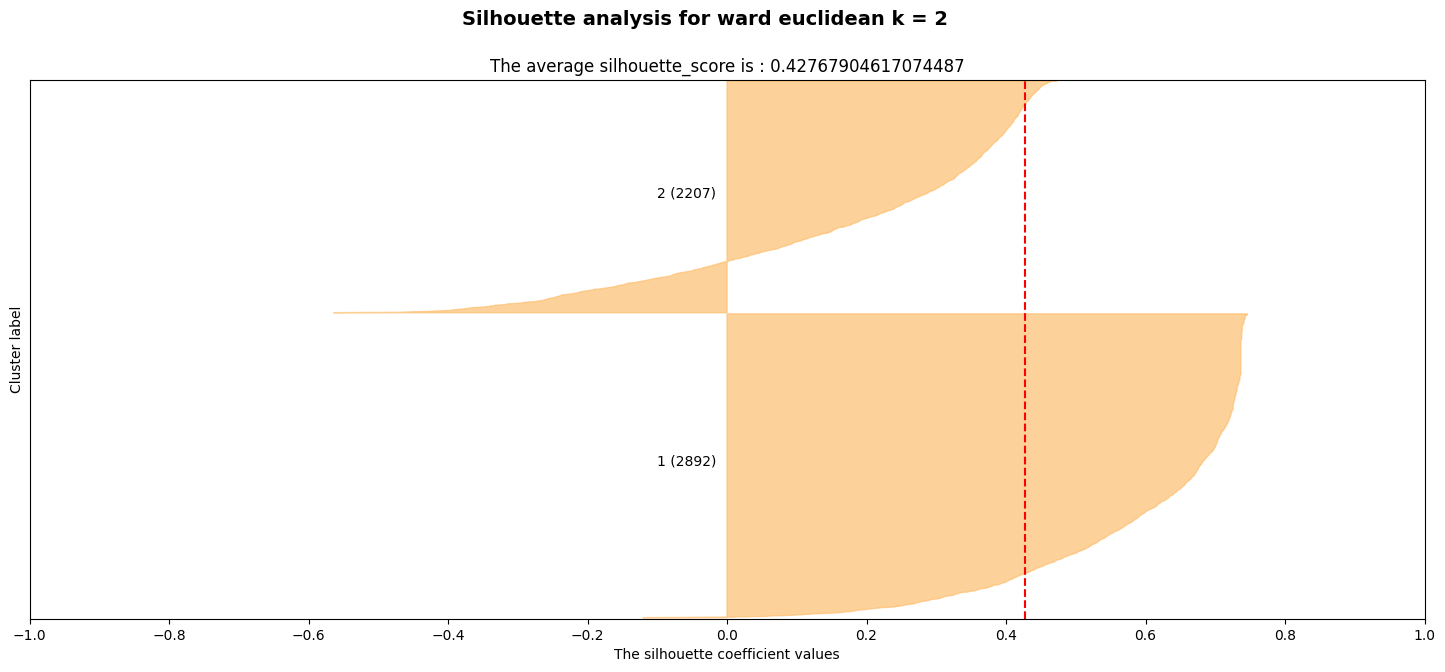

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.34327220301859634
 Average cluster 1: 0.4912503992822272
 Average cluster 2: 0.12381458508503637
 Average cluster 3: 0.18676654879542307


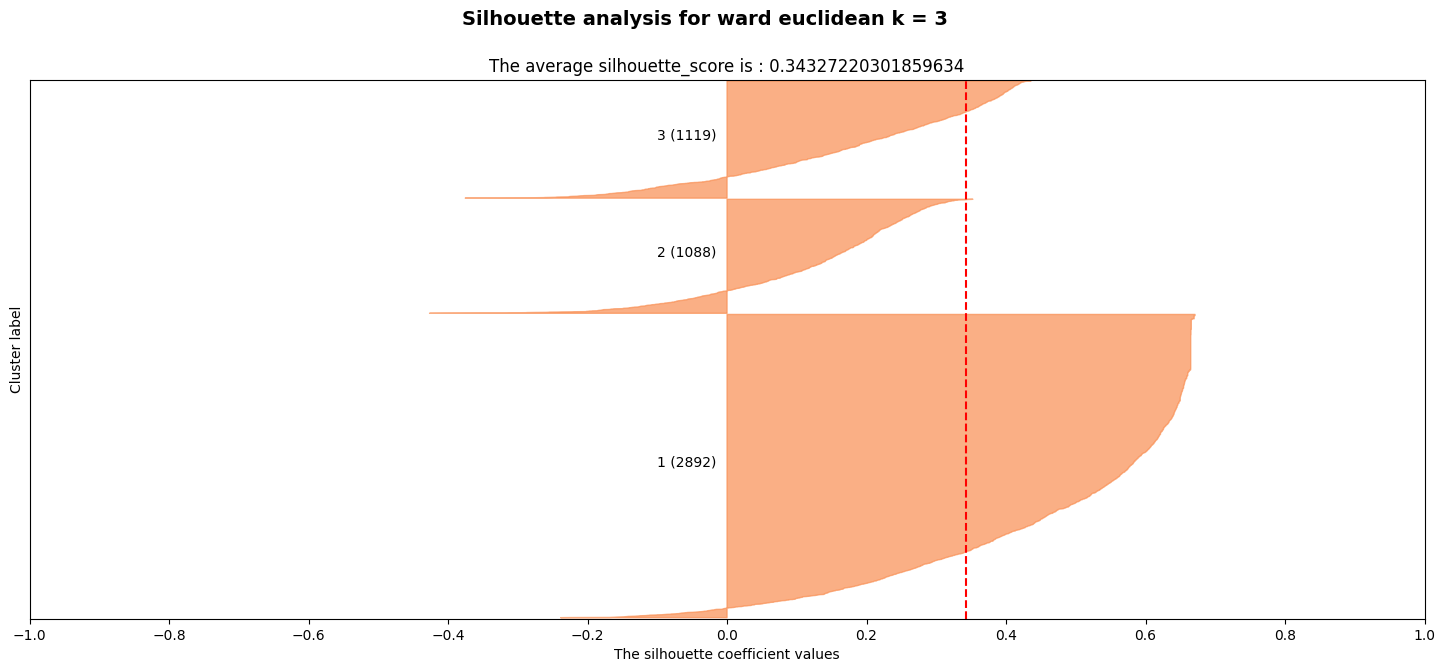

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.2250036729940361
 Average cluster 1: 0.507439301690839
 Average cluster 2: -0.02539941576152889
 Average cluster 3: 0.026111757538572696
 Average cluster 4: 0.265243582679961
 Average cluster 5: 0.05645767863930664


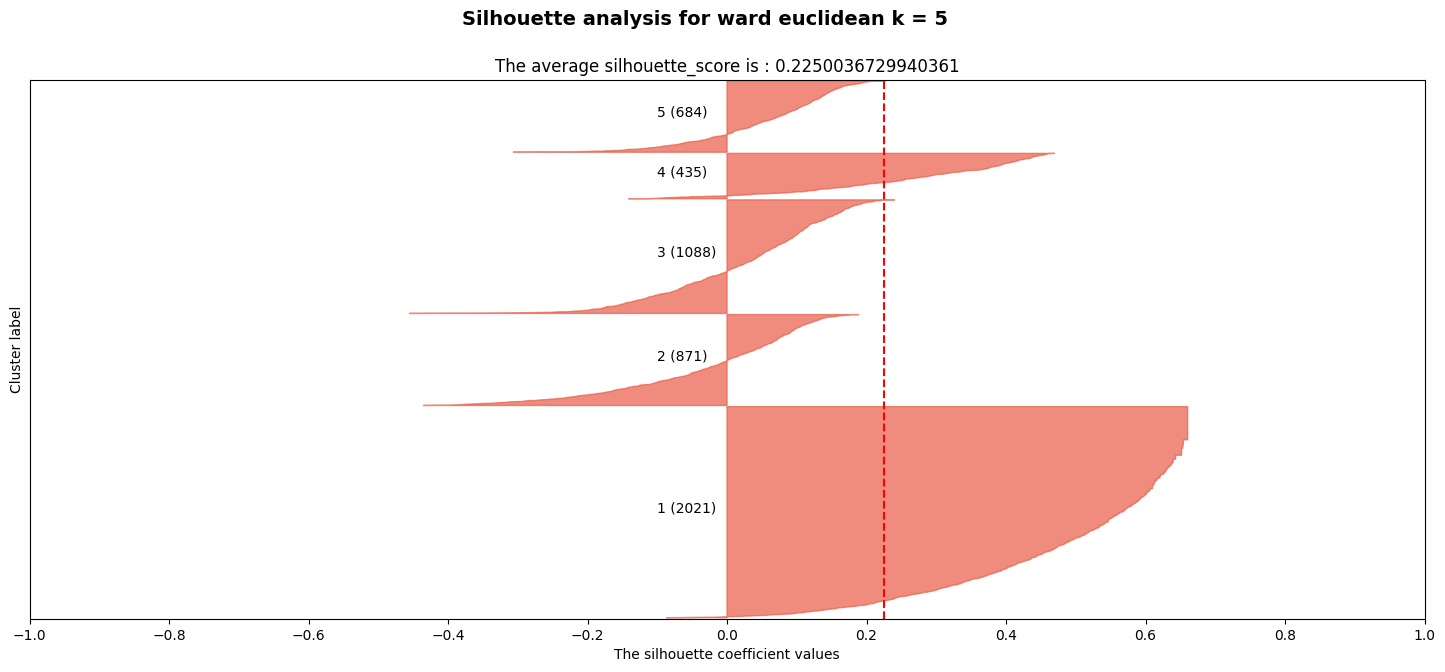

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.2224676187489907
 Average cluster 1: 0.5074366484519803
 Average cluster 2: -0.03250655223353633
 Average cluster 3: 0.08641315083030002
 Average cluster 4: 0.015587167950337173
 Average cluster 5: 0.2261049258047157
 Average cluster 6: 0.1223084587502341
 Average cluster 7: 0.08206281475950197


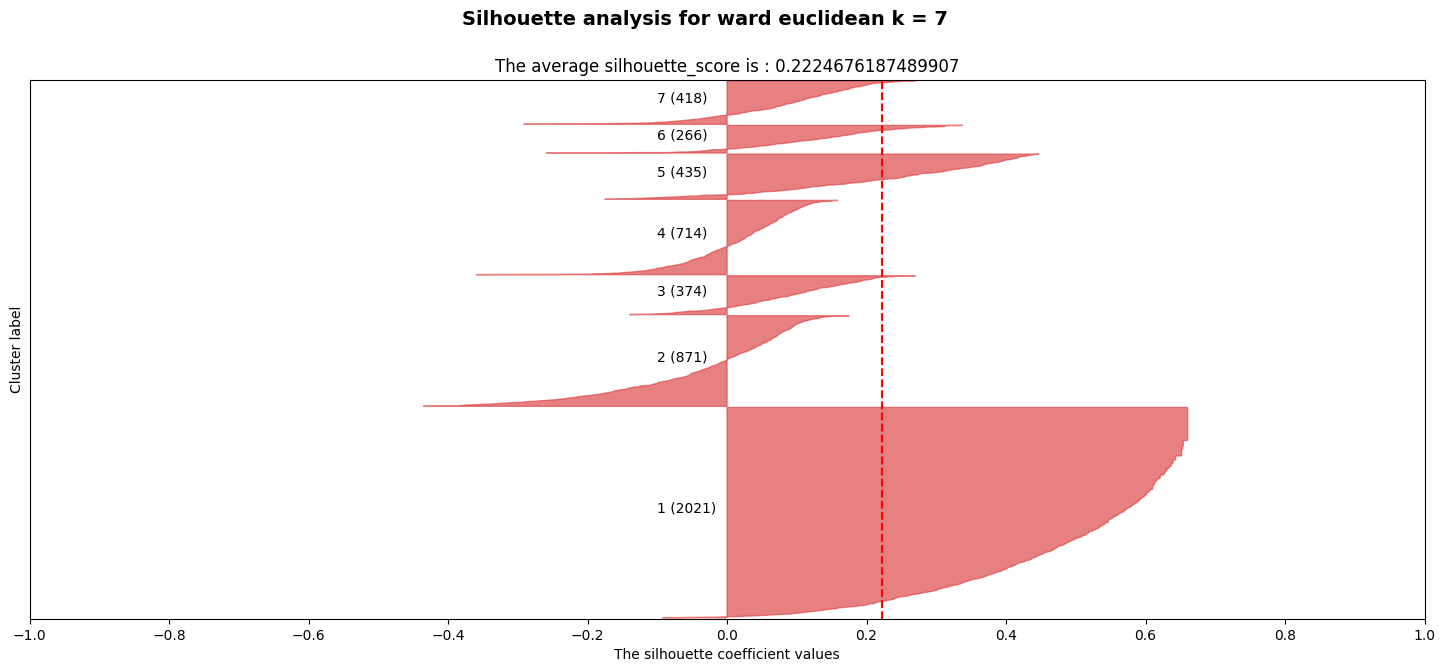

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.4326432150584346
 Average cluster 1: 0.4239683756744507
 Average cluster 2: 0.5176225297295248


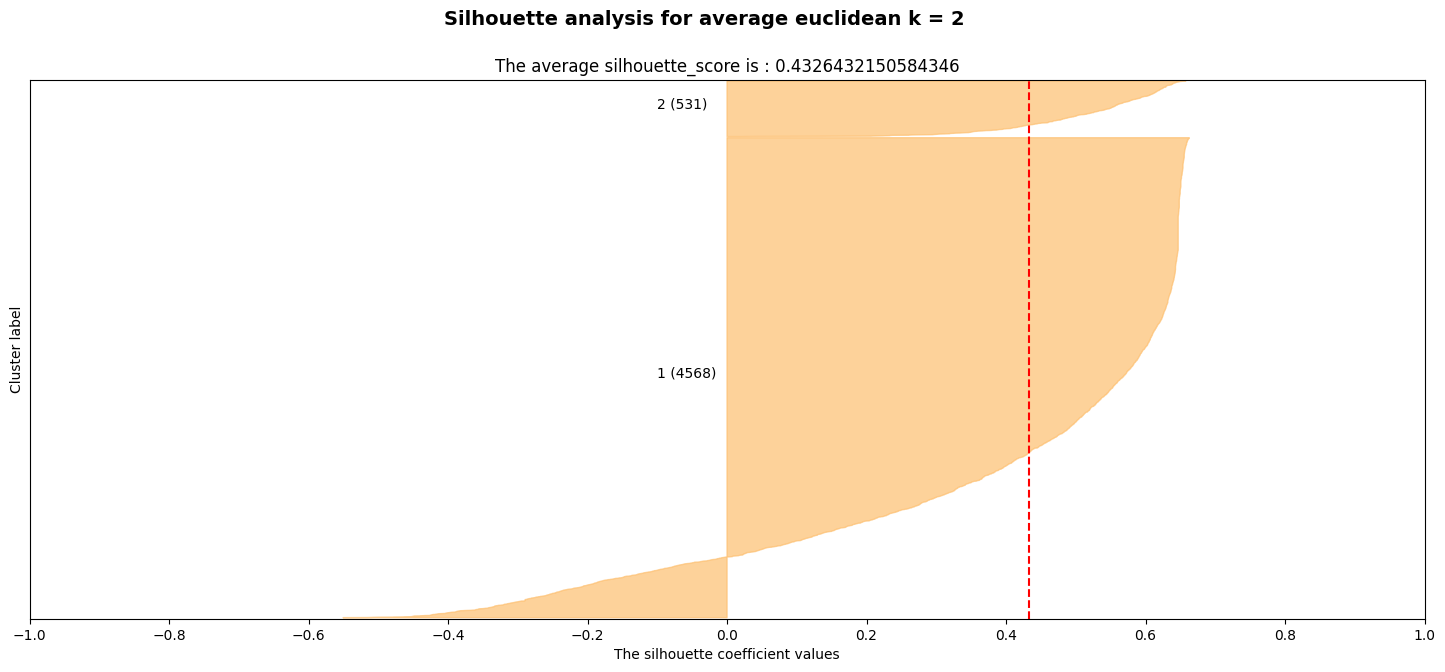

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.4184157765581237
 Average cluster 1: 0.42333787606836776
 Average cluster 2: 0.388321206885535
 Average cluster 3: 0.0


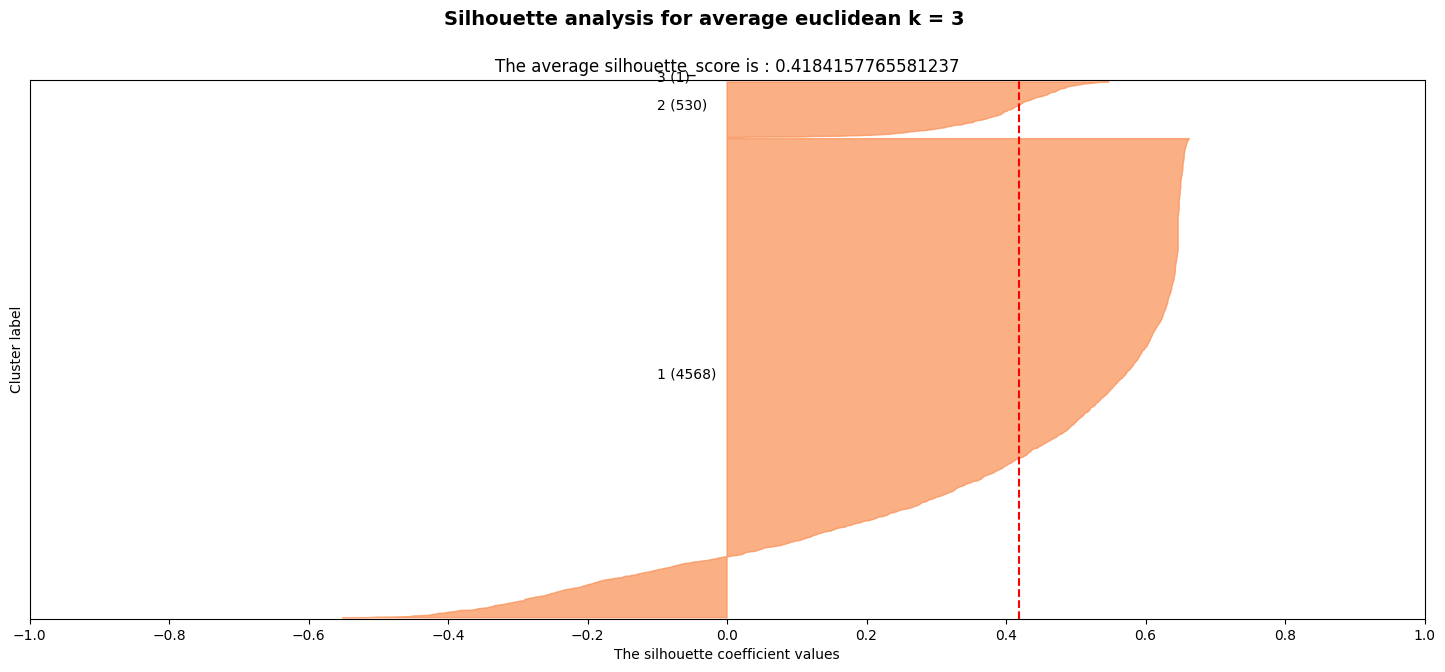

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.3686194117675666
 Average cluster 1: 0.5276647245421577
 Average cluster 2: 0.10538657610344279
 Average cluster 3: 0.2423455195448059
 Average cluster 4: 0.3527401137842021
 Average cluster 5: 0.0


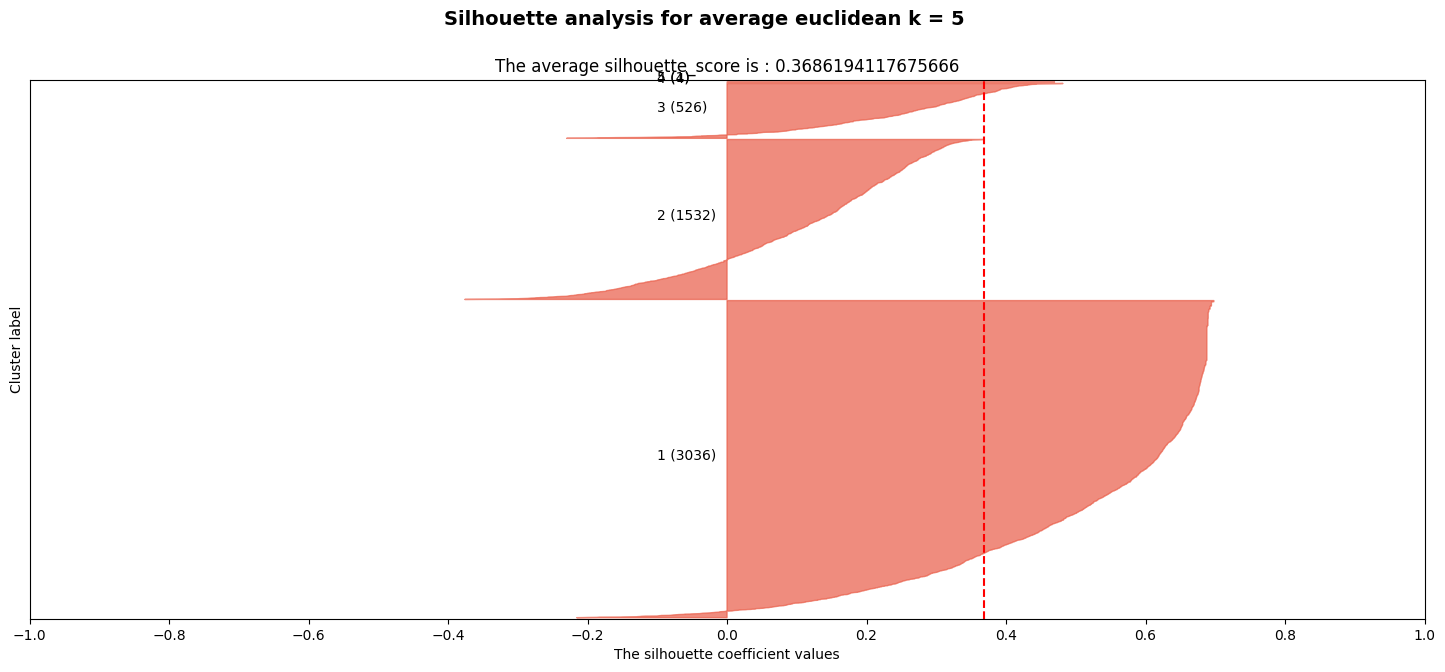

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.4836641865190875
 Average cluster 1: 0.5111815081444011
 Average cluster 2: 0.1949930644875556
 Average cluster 3: 0.4967284892928374


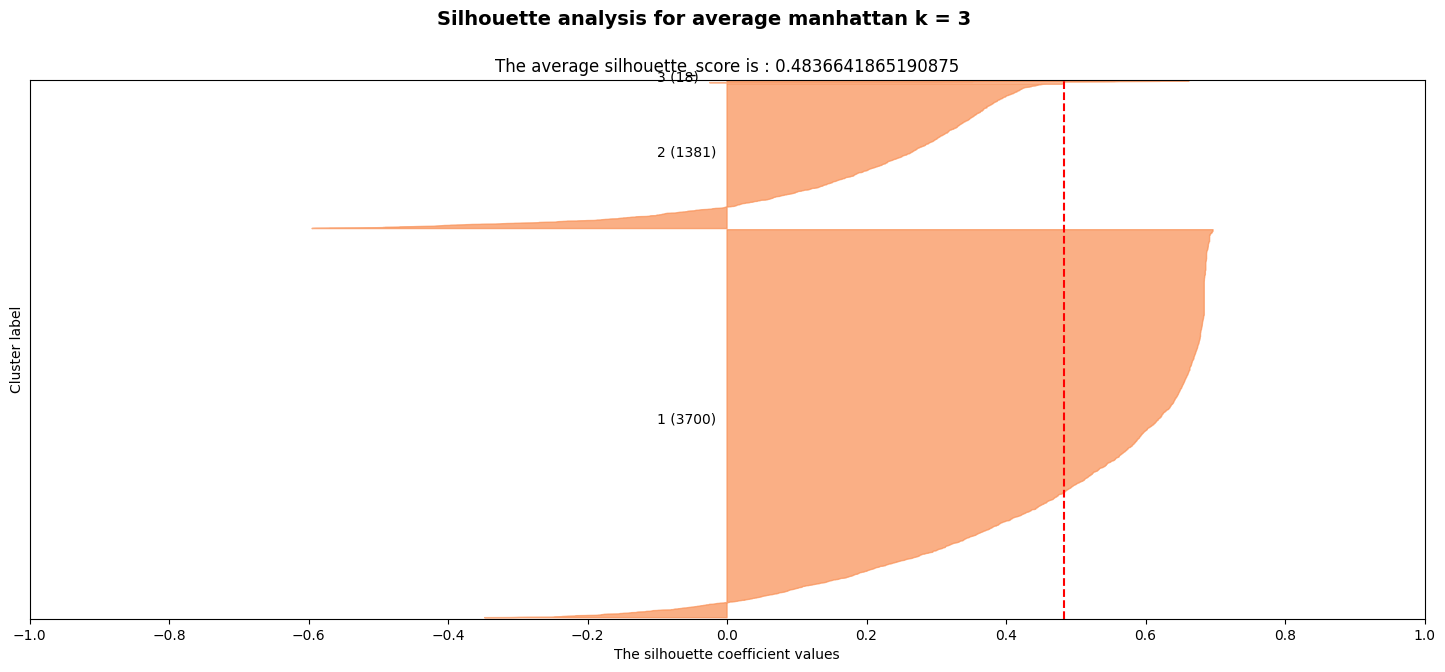

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.3574420098494276
 Average cluster 1: 0.4456153251215733
 Average cluster 2: 0.394657942189296
 Average cluster 3: 0.4113781825102998
 Average cluster 4: 0.12706495401353404
 Average cluster 5: 0.5395965496929669
 Average cluster 6: 0.0


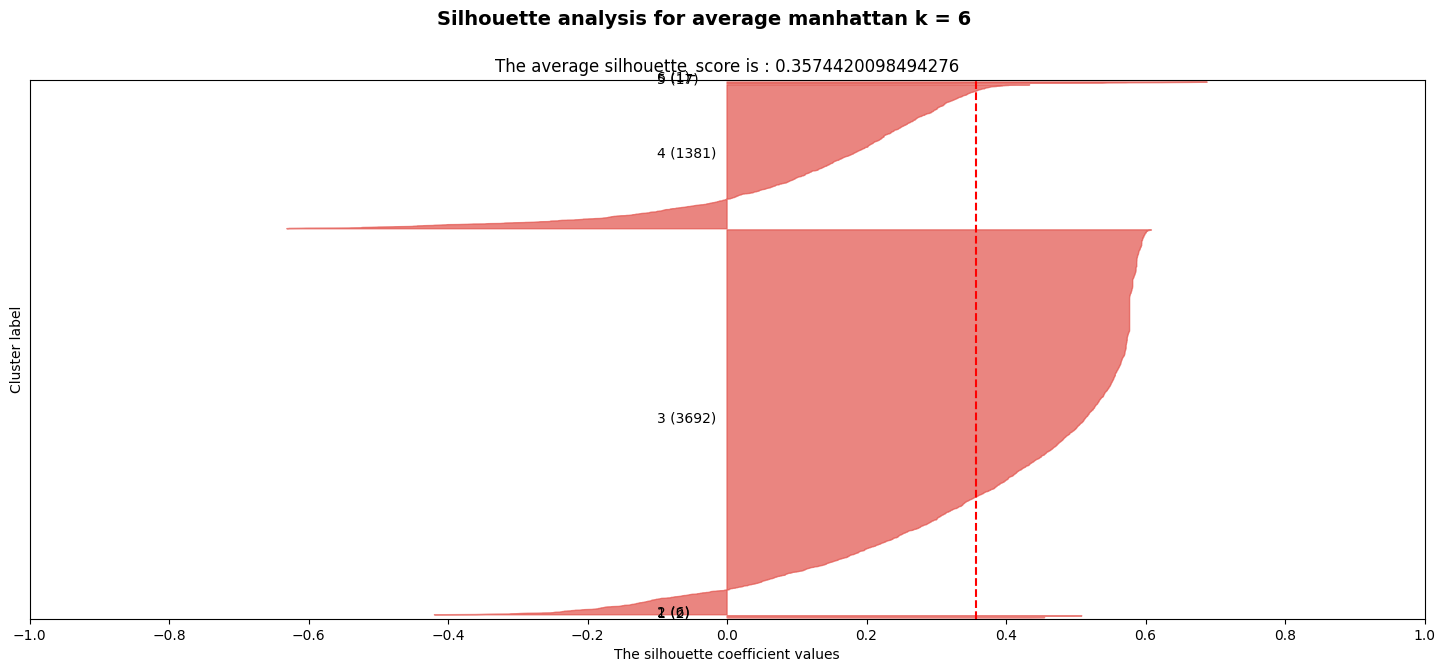

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.42386437799390964
 Average cluster 1: 0.595933484433303
 Average cluster 2: 0.41102460382168726


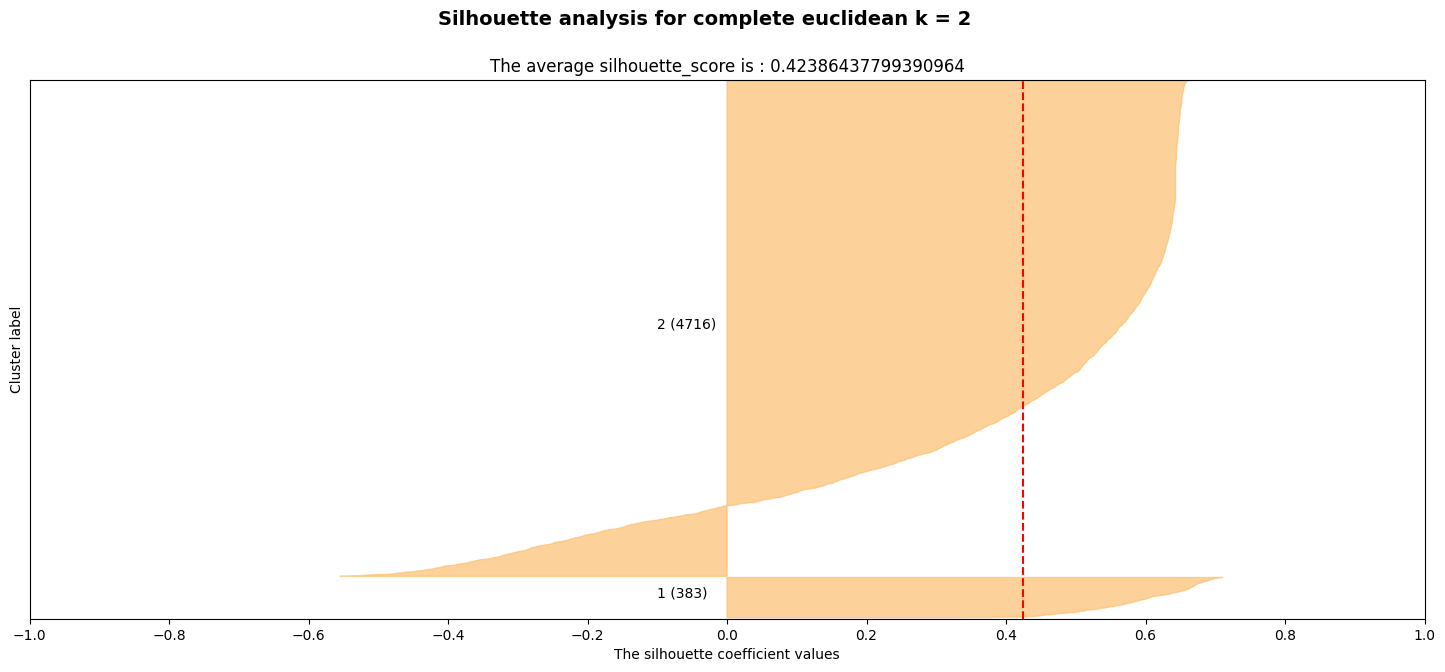

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.38692834798393444
 Average cluster 1: 0.3720434632501898
 Average cluster 2: 0.45908651549637186
 Average cluster 3: 0.151072073787795


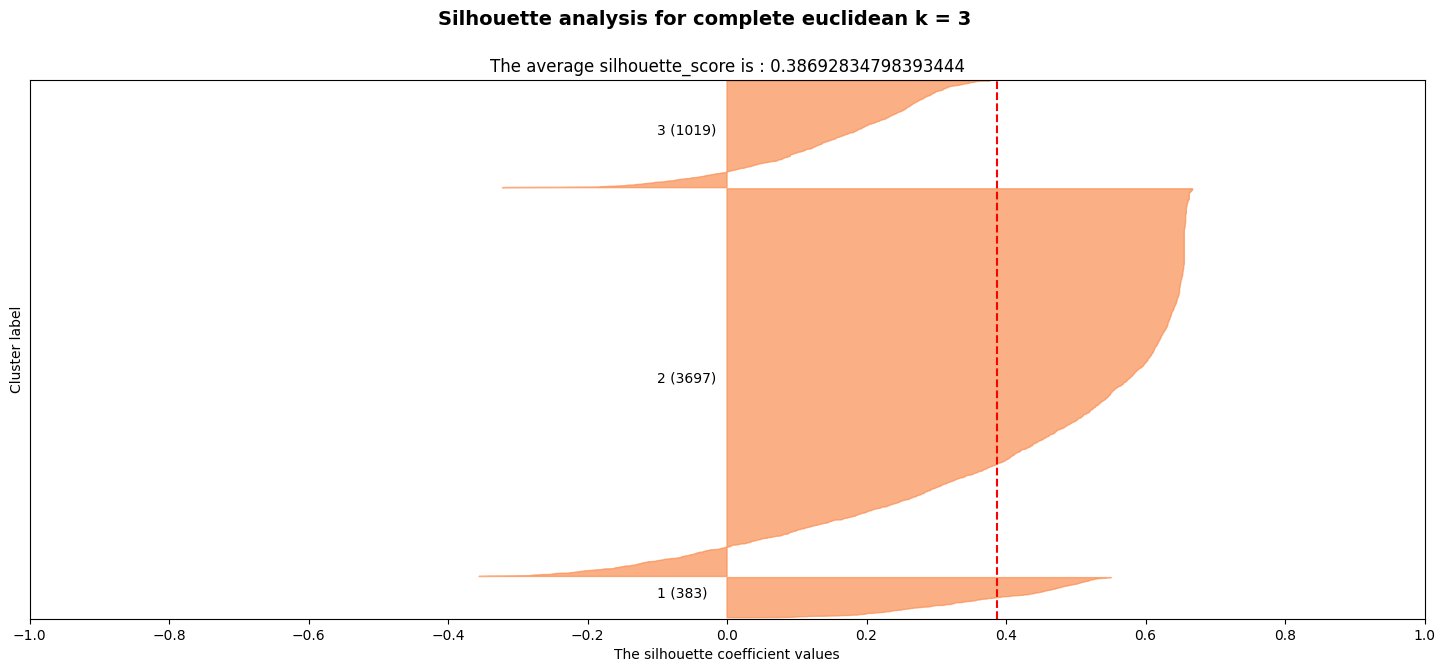

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.3618461784306356
 Average cluster 1: 0.2846094845436339
 Average cluster 2: 0.4536975364568108
 Average cluster 3: 0.10326998336861344
 Average cluster 4: 0.0927269086401786


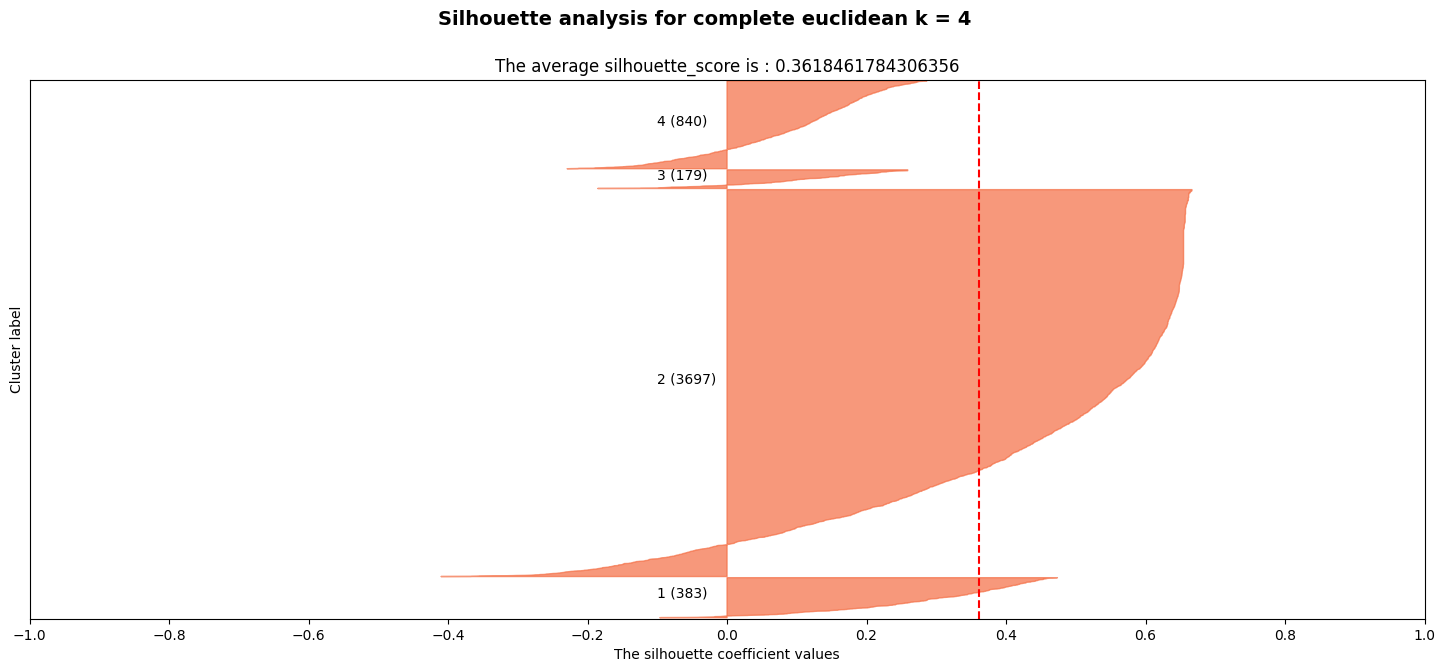

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.48047495606226454
 Average cluster 1: 0.4431227274557484
 Average cluster 2: 0.42740655890529533


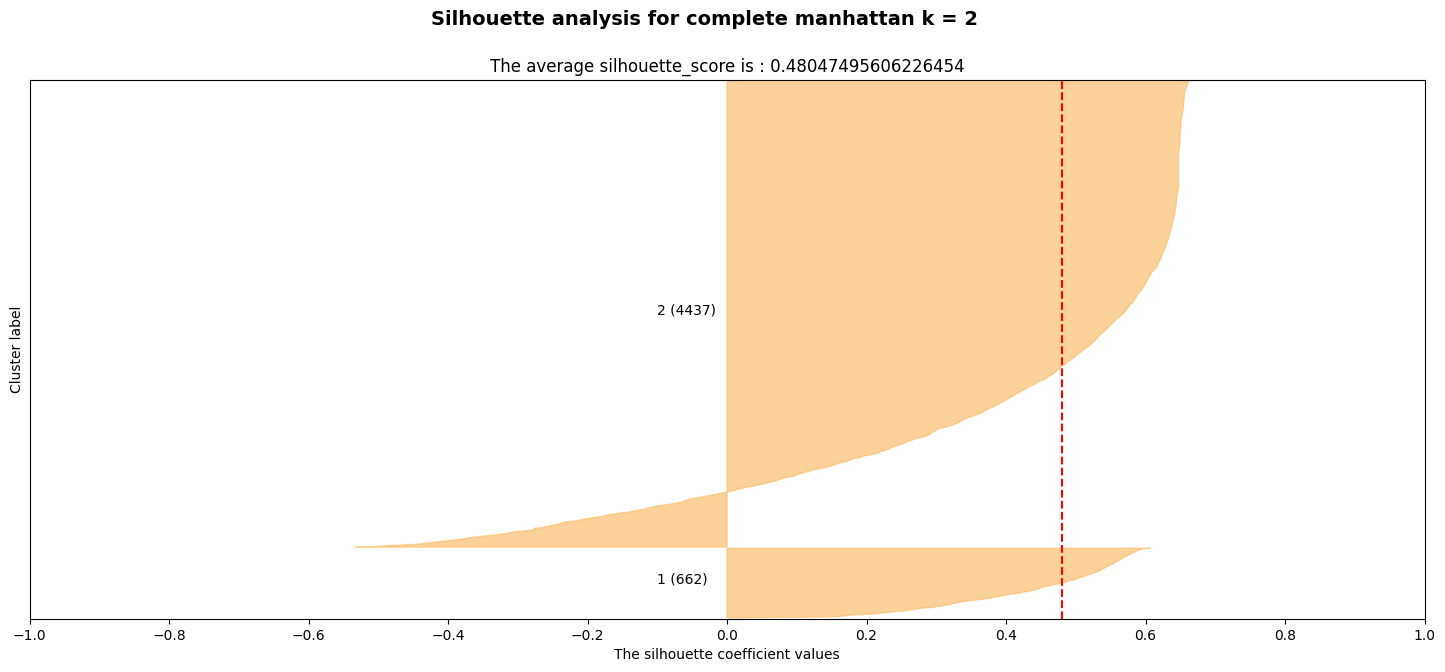

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.4019384110985486
 Average cluster 1: 0.19281005149686808
 Average cluster 2: 0.44559361880057835
 Average cluster 3: 0.1335638738577439


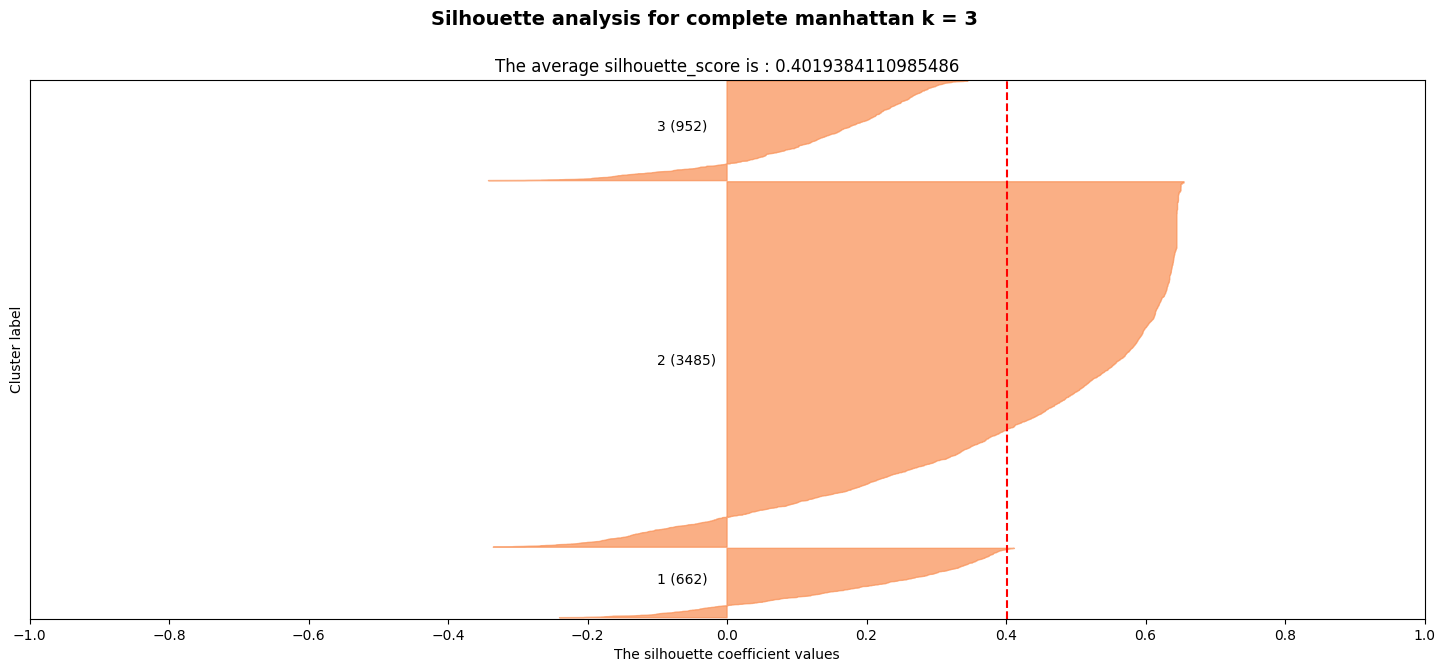

In [16]:
# print(cluster_columns)

for describe_cluster in cluster_columns:
    compute_silhouette_plot(configs, psaid12[columns_gp + [describe_cluster]], columns_gp, describe_cluster)

### t-SNE Plots

In [17]:
## Compute t-SNE 2D

def tSNE_2D(data, cluster_columns, columns_gp, RandomSeed, figure_storage):
    tsne2D = pd.DataFrame(TSNE(n_components=2, random_state=RandomSeed).fit_transform(data[columns_gp]), columns=['tSNE1', 'tSNE2'])

    for describe_clusters in cluster_columns:
        ## Add clusterIDs
        tsne2D[describe_clusters] = data[describe_clusters]
        
        ## Plot t-SNE Visualisation
        plt.figure(figsize=(8, 6))
        plt.scatter(tsne2D['tSNE1'], tsne2D['tSNE2'], c=tsne2D[describe_clusters], cmap='viridis', alpha=0.7)
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        plt.title(f'2D t-SNE Visualization of {describe_clusters}')
        #ax.legend([0, 1, 2, 3])
        plt.show()
    
        ## Save Figure
        #fig.suptitle(f'PsAID clustering, {describe_clusters}', y=1.02, fontsize=20)
        # plt.savefig(os.path.join(figure_storage, f'PsAID_{describe_clusters}_tSNE.png'))
        #plt.show 

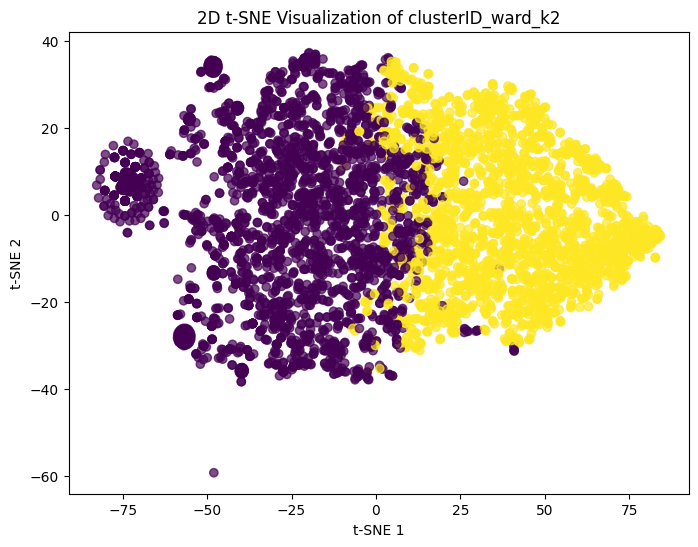

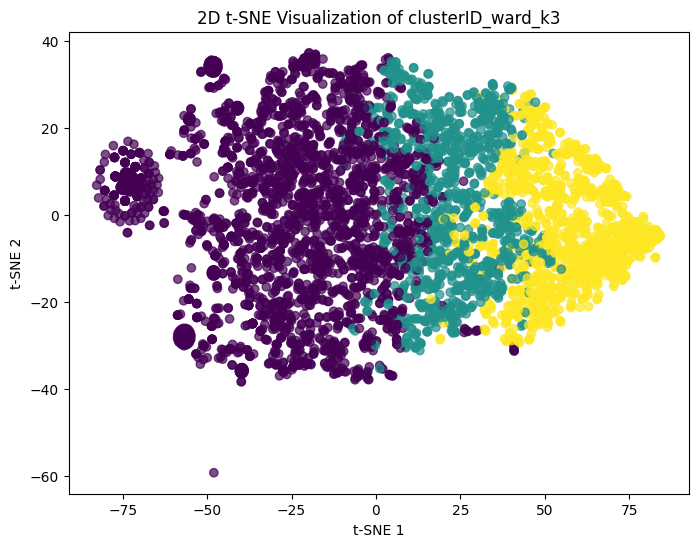

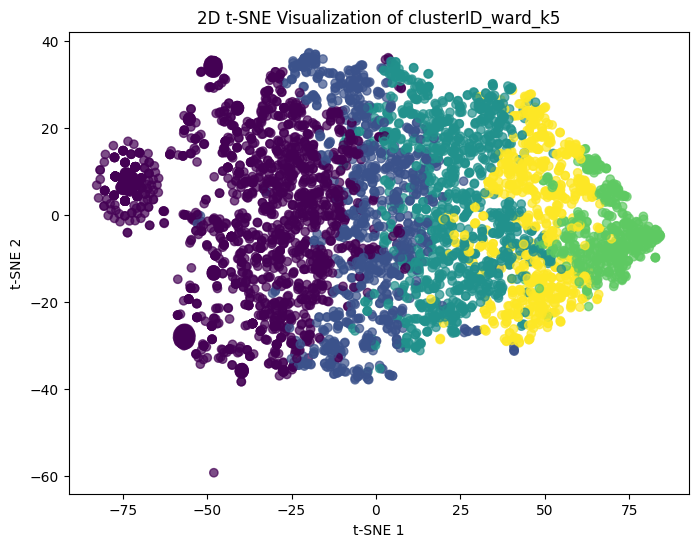

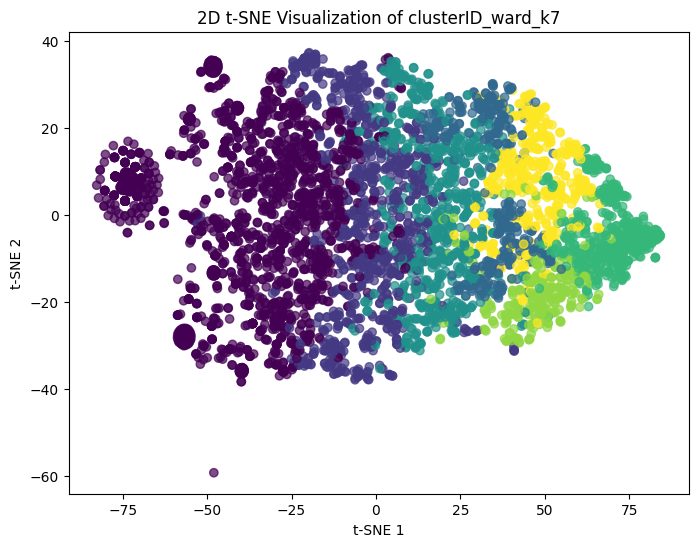

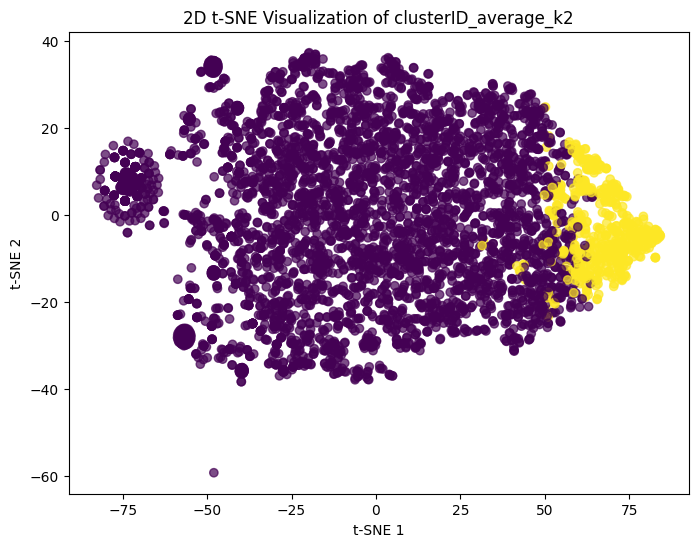

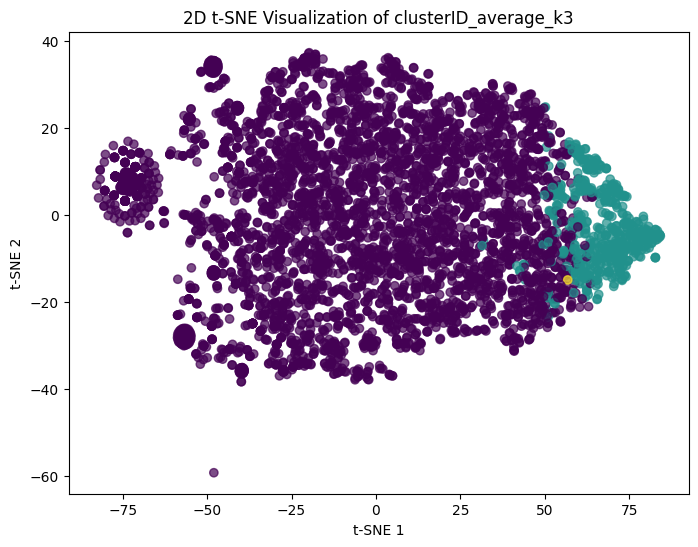

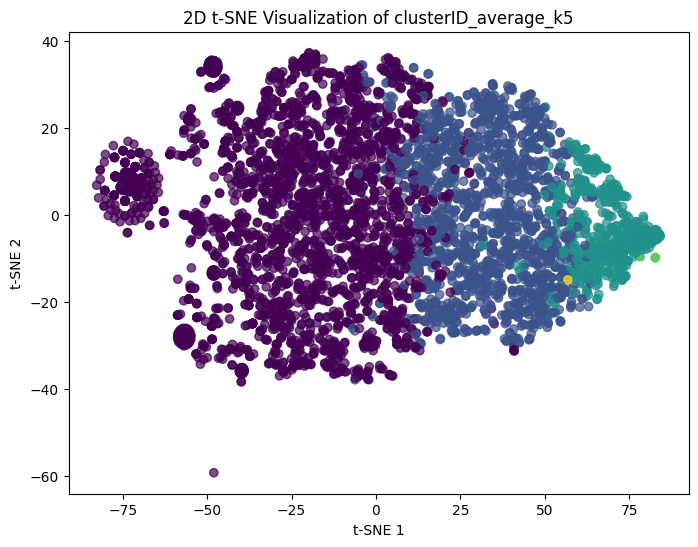

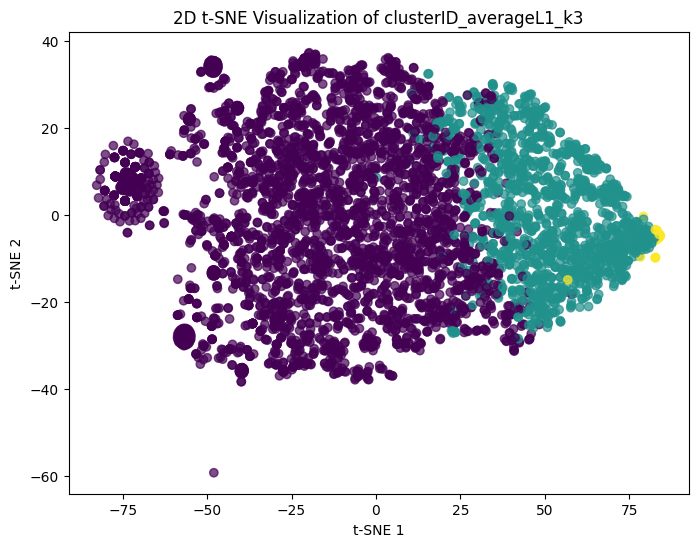

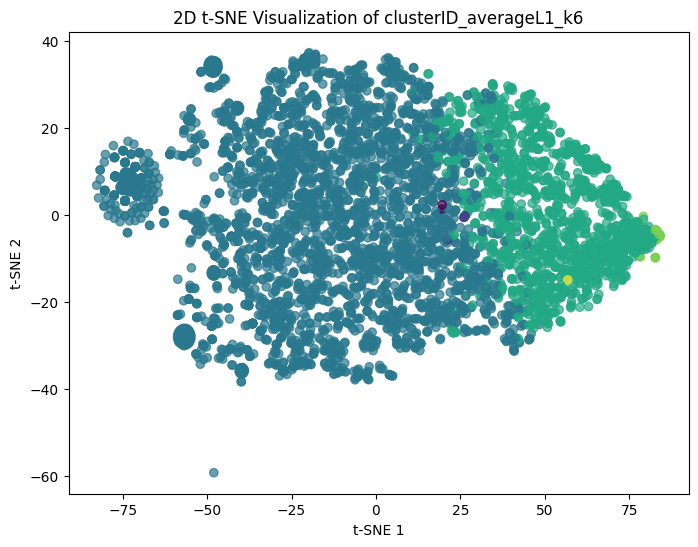

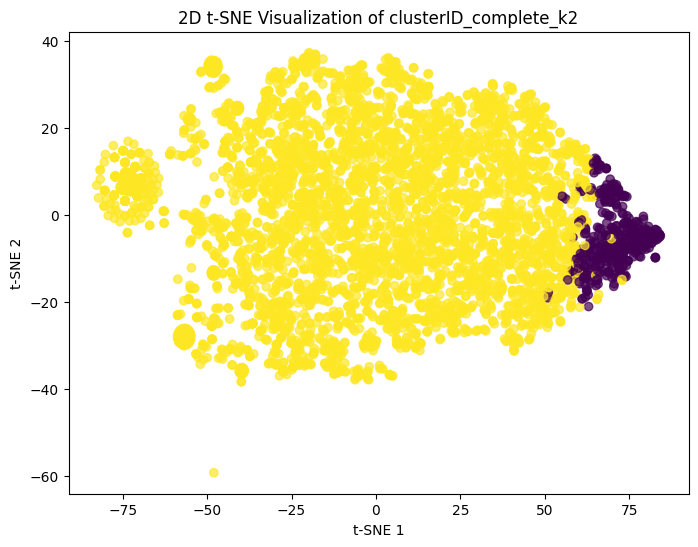

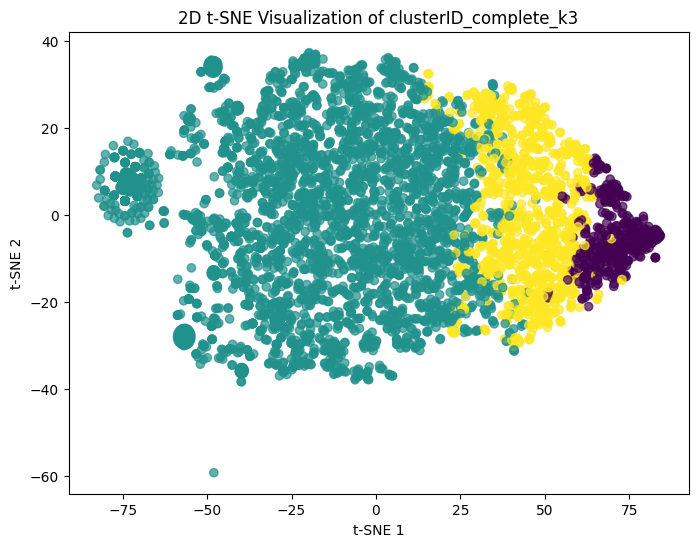

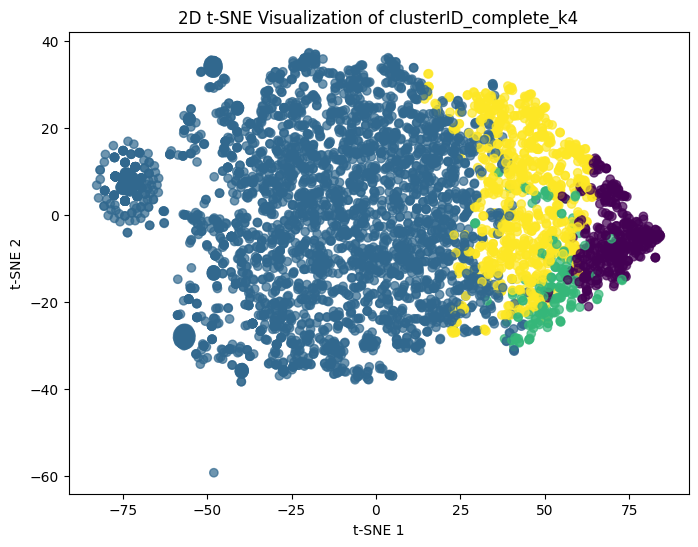

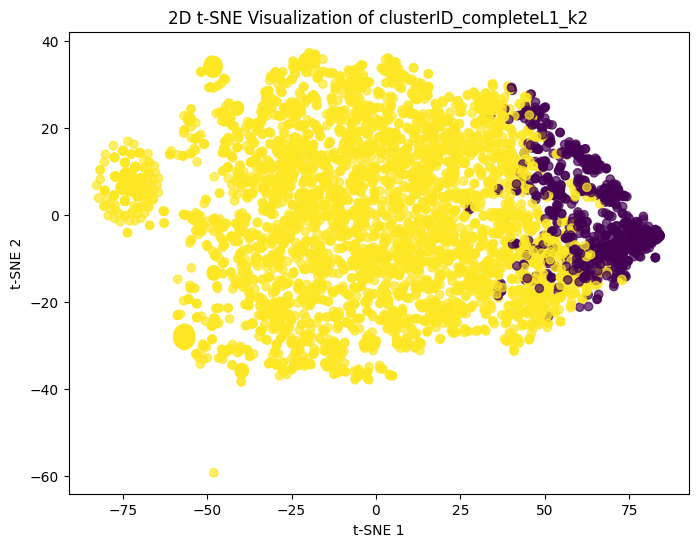

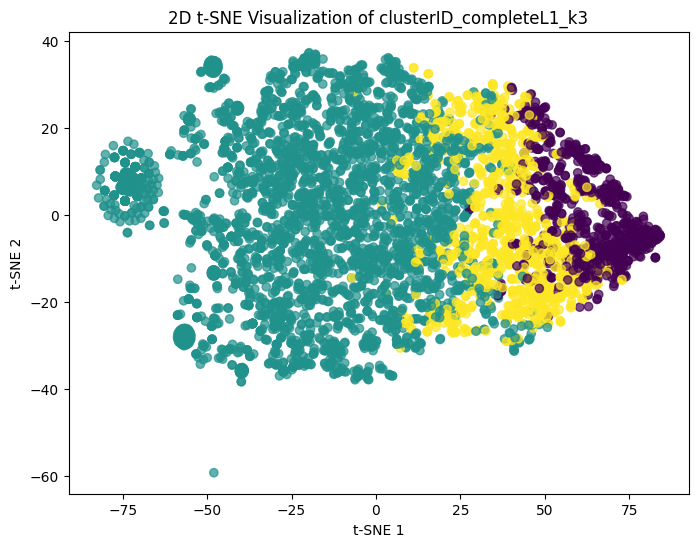

In [18]:
tSNE_2D(psaid12, cluster_columns, columns_gp, RandomSeed, figure_storage)

### Save Clustering Results

In [19]:
folder_path = data_storage
file_name = "PsAID_Hierarchical Clustering_Clusters"

# Ensure the folder exists
os.makedirs(folder_path, exist_ok=True)

# Save
psaid12.to_csv(f'{folder_path}/{file_name}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name}.csv')

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Hierarchical Clustering/PsAID_Hierarchical Clustering_Clusters.csv


## Robustness

In [20]:
def HAC_clustering(data, k, linkage_type, RandomSeed, columns_gp, suffix):
    """
    Because our dataset is based on whole numbers [0-10], the ward ward clustering is sensitive to the scale of the data. 
    There is higher similarity because of the lack of variance. Meaning that when scaled ties are assigned differently.
    """
    
    if linkage_type.startswith('ward'):
        link = 'ward'
        distance_metric = 'euclidean' # Ward can only be performed with euclidean distance
    elif linkage_type.startswith('average'):
        link = 'average'
        if linkage_type.endswith('L1'):
            distance_metric = 'manhattan'
        else:
            distance_metric = 'euclidean'
    elif linkage_type.startswith('complete'):
        link = 'average'
        if linkage_type.endswith('L1'):
            distance_metric = 'manhattan'
        else:
            distance_metric = 'euclidean'
            
    if distance_metric == 'manhattan':
        linkage_matrix_distance = 'cityblock'
        distance_suffix = 'L1'
    else:
        linkage_matrix_distance = distance_metric
        distance_suffix = ''

    print(link, distance_metric)
    
    # Run agglomeration algorithm
    HAC = AgglomerativeClustering(n_clusters=10, linkage = link, metric = distance_metric).fit(data[columns_gp])
    
    # Create linkage matrix
    linkage_matrix = linkage(data[columns_gp], method=link, metric = linkage_matrix_distance)
    
    # Assign Clusters
    cluster_assignment = fcluster(linkage_matrix, k, criterion = 'maxclust') #flcuster outputs clusters as 1-K, but we need 0-K for consistency across techniques
    n_clusters = len(np.unique(cluster_assignment))

    """ Cuts can produce different n_clusters, therefor use K. Kan be that K=3 has 4 clusters """
    clusterID = f'clusterID_{linkage_type}_k{k}{suffix}' #
    
    data[clusterID] = cluster_assignment
    # print(data.head())
    
    del HAC
    return data

In [21]:
# Split sample and generate clusters with datasplit
def split_sample_clustering(data, k, linkage_type, RandomSeed, columns_gp):
    print(linkage_type)
    #Split dataset in 2 equal parts
    print('Split sample in half:')
    data_split1, data_split2 = train_test_split(data[['respondentid', 'mm']+ columns_gp], test_size=0.5, random_state=RandomSeed)
    """ Indexes are kept when the dataset is split """

    # Check if both samples have the same shape
    print("Split 1 shape: ", data_split1.shape) 
    print("Split 2 shape: ", data_split2.shape)

    # Run clustering for split 1
    suffix = "_split1"
    psaid12_split1 = HAC_clustering(data_split1, k, linkage_type, RandomSeed, columns_gp, suffix)

    # Subset the full cluster analysis based on the indexes of the test dataset
    # And check if the test dataset and the subset of the complete dataset are equal
    split_indexes = data_split1.index # Get indexes of the datapoints included
    print(f'clusterID_{linkage_type}_k{k}')
    data_ss_subset = data[['respondentid', 'mm']+ columns_gp + [f'clusterID_{linkage_type}_k{k}']].loc[split_indexes] # Subset the full dataset based on these indexes
    print("Complete_subset shape: ", data_ss_subset.shape)
    print(f'Equality between complete_subsetted and split1 is: {data_ss_subset[['respondentid', 'mm'] + columns_gp].equals(data_split1[['respondentid', 'mm'] + columns_gp])} \n') # Check equality True or False

    print(data_ss_subset)
    
    return psaid12_split1, data_ss_subset

# Establish parity between the assigned clusters generated with the full and split data.
def match_clusters(data1, cluster_name1, data2, cluster_name2, k, byvar):
    """
    Function that pairs the cluster centers by closeness. 
    It is used to establish the same cluster codes between algorithms.
    """

    print('Match clusters')

    data1 = data1.copy()
    data1[cluster_name1] = data1[cluster_name1]-1
    data2 = data2.copy()
    data2[cluster_name2] = data2[cluster_name2]-1

    print(f'data1: {data1[cluster_name1].unique()}')
    print(f'data2: {data2[cluster_name2].unique()}')

    centers1 = data1[byvar + [cluster_name1]].groupby(cluster_name1).mean().values
    centers2 = data2[byvar + [cluster_name2]].groupby(cluster_name2).mean().values

    if len(centers1)!= len(centers2):
        comment = 'One cluster is empty, leading to unequal number of clusters'
        return data2, comment
        
    # Find Closest Clusters
    distances = cdist(centers1, centers2, metric='euclidean') #Compute pairwise distances
    print("Pairwise Euclidean distances between cluster centers:\n", distances)
    # print("Each row in the distances matrix corresponds to a cluster from data1. Each column in the distances matrix corresponds to a cluster from data2. \n")

    row_ind, col_ind = linear_sum_assignment(distances) #Match clusters using the Hungarian algorithm
    cluster_mapping = dict(zip(col_ind, row_ind)) # Create a mapping from data1 to data2
    
    print(f'Cluster mapping (data2 -> data1): {cluster_mapping} \n')
 
    ## Remap Cluster Assignments
    def remap_labels(labels, mapping):
        """
        Remap cluster labels based on a mapping dictionary.
        :param labels: Original cluster labels.
        :param mapping: Mapping dictionary (e.g., {0: 1, 1: 0, ...}).
        :return: Remapped cluster labels.
        """
        return np.array([mapping[label] for label in labels])

    data2[cluster_name2+'_OG'] = data2[cluster_name2].astype('category')
    data2[cluster_name2] = remap_labels(data2[cluster_name2], cluster_mapping) #Remap cluser assignments
    data2[cluster_name2] = data2[cluster_name2].astype('category') # Convert from int to category

    ## Remap Cluster Centers
    cluster_centers = {
        f'data1': [data1.groupby(cluster_name1)[columns_gp].mean().values], #Compute cluster means
        f'data2': [data2.groupby(cluster_name2)[columns_gp].mean().values]  #Compute cluster means
    }  
    
    # Check if correct
    table = pd.DataFrame({
        f'data1': pd.Series(data1[cluster_name1]).value_counts(),
        f'Original {data2} data2': pd.Series(data2[cluster_name2+'_OG']).value_counts(),
        f'Remapped {data2} data2': pd.Series(data2[cluster_name2]).value_counts()
    }).sort_index()
    
    # print(table)

    # Define output
    comment = ""
    return data2, comment

# Compute similarity with the Adjusted Rand Index
def compute_ARI(ARI_stored, estimator1, estimator2, describe_cluster, suffix, comment):
    """
    The Adjusted Rand Index (ARI): a measure used to evaluate the similarity between two data clusterings. 
    It is an adjustment of the Rand Index (RI), which counts the number of pairs of elements that are either both in the same cluster or both in different clusters in the predicted and true clusterings. 
    The ARI adjusts for the chance grouping of elements, providing a more accurate measure of clustering similarity. 
    The ARI adjusts the RI by considering the expected similarity of all pairwise comparisons based on chance. 
    This adjustment makes the ARI more reliable and interpretable, especially when comparing different clustering results.
    
    The ARI score ranges from -1 to 1.
    1 = identical clustering 0 = similarity is no better than what would be expected by chance -1 = two clusters are less similar than random clustering (strongly disagreeing)
    """

    if comment != "":
        ari = np.NAN
    else:
        ari = adjusted_rand_score(estimator1, estimator2)
        print(f'Adjusted Rand Index: {ari} \n')


    if suffix == '_split1':
        ari_computed = '_split_sample'
    elif re.match(r'_no_gp\d{2}$', suffix):
            ari_computed = '_variable_validation'
    
    ARI_dict = {
        'cluster_name': describe_cluster,
        f'ARI{ari_computed}': ari,
        'comments': comment
    }
    
    ARI_stored.append(ARI_dict)
    
    return ARI_stored

def split_sample_validation(ARI_split_sample, data, describe_cluster, RandomSeed, columns_gp):
    linkage_type = re.search(r'clusterID_(.*?)_k', describe_cluster).group(1)
    print(linkage_type)
    k = int(re.search(r'k(\d+)', describe_cluster).group(1))
    print(k)
    
    data_split1_clusters, data_complete_clusters_subset = split_sample_clustering(psaid12, k, linkage_type, RandomSeed, columns_gp)
    data_split1_clusters_matched, comment = match_clusters(data_complete_clusters_subset, describe_cluster, data_split1_clusters, describe_cluster+'_split1', k, columns_gp)
    ari_split_sample = compute_ARI(ARI_split_sample, data_split1_clusters_matched[describe_cluster+'_split1'], data_complete_clusters_subset[describe_cluster], describe_cluster, '_split1', comment)
    ari_split_sample = pd.DataFrame(ari_split_sample)
    
    return ari_split_sample


## Split-Sample Validation

In [22]:
# if computeARIs == True:
ARI_split_sample = []
    
for describe_cluster in cluster_columns:
        with contextlib.redirect_stdout(io.StringIO()): #Suppress prints inside the function.
            ari_split_sample  = split_sample_validation(ARI_split_sample, psaid12, describe_cluster, RandomSeed, columns_gp)
        print(f'computed ARI {describe_cluster}')
  
pd.DataFrame(ari_split_sample)

computed ARI clusterID_ward_k2
computed ARI clusterID_ward_k3
computed ARI clusterID_ward_k5
computed ARI clusterID_ward_k7
computed ARI clusterID_average_k2
computed ARI clusterID_average_k3
computed ARI clusterID_average_k5
computed ARI clusterID_averageL1_k3
computed ARI clusterID_averageL1_k6
computed ARI clusterID_complete_k2
computed ARI clusterID_complete_k3
computed ARI clusterID_complete_k4
computed ARI clusterID_completeL1_k2
computed ARI clusterID_completeL1_k3


,cluster_name,ARI_split_sample,comments
0,clusterID_ward_k2,0.412931,
1,clusterID_ward_k3,0.449132,
2,clusterID_ward_k5,0.621592,
3,clusterID_ward_k7,0.637671,
4,clusterID_average_k2,0.651819,
5,clusterID_average_k3,0.652078,
6,clusterID_average_k5,0.395030,
7,clusterID_averageL1_k3,0.664715,
8,clusterID_averageL1_k6,NaN,"One cluster is empty, leading to unequal numbe..."
9,clusterID_complete_k2,0.490643,


## Leave one Out

In [23]:
def variable_validation(ARI_LeaveOneOut, data, describe_cluster, suffix, Randomseed, varlist):
    linkage_type = re.search(r'clusterID_(.*?)_k', describe_cluster).group(1)
    k = int(re.search(r'k(\d+)', describe_cluster).group(1))
    
    # Run clustering without varB
    data_varlistB_clusters = HAC_clustering(data, k, linkage_type, RandomSeed, varlist, suffix)
    
    if len(data_varlistB_clusters[describe_cluster+suffix].unique()) != k:
        comment = 'unequal number of clusters'
    else:
        comment = ""
    
    # Match clusters computed with and without varB
    data_varlistB_matched =  data_varlistB_clusters # match_clusters(psaid12, describe_cluster, data_varlistB_clusters, describe_cluster+suffix, varlist)

    # ARI
    ari_LeaveOneOut = compute_ARI(ARI_LeaveOneOut, data_varlistB_matched[describe_cluster+suffix], data[describe_cluster], describe_cluster+suffix, suffix, comment)
    
    return data_varlistB_clusters, ari_LeaveOneOut
    

In [33]:
ARI_LeaveOneOut = []
    
for describe_cluster in cluster_columns:
    for var in columns_gp:
        varlistB = [i for i in psaid12.columns if re.match(r'^gp\d{2}$', i) and i != var]
        with contextlib.redirect_stdout(io.StringIO()): #Suppress prints inside the function.
            data_varlistB_clusters, ari_LeaveOneOut  = variable_validation(ARI_LeaveOneOut, psaid12, describe_cluster, f'_no_{var}', RandomSeed, varlistB)
        print(f'computed ARI {describe_cluster}, without {var} ({domains_dict[var]})')
        
ARI_LeaveOneOut = pd.DataFrame(ari_LeaveOneOut).copy()
ARI_LeaveOneOut

computed ARI clusterID_ward_k2, without gp01 (Pain)
computed ARI clusterID_ward_k2, without gp02 (Fatigue)
computed ARI clusterID_ward_k2, without gp03 (Skin)
computed ARI clusterID_ward_k2, without gp04 (Work-recreational activities)
computed ARI clusterID_ward_k2, without gp05 (Bodily functioning)
computed ARI clusterID_ward_k2, without gp06 (Discomfort)
computed ARI clusterID_ward_k2, without gp07 (Sleep)
computed ARI clusterID_ward_k2, without gp08 (Coping)
computed ARI clusterID_ward_k2, without gp09 (Anxiety)
computed ARI clusterID_ward_k2, without gp10 (Shame)
computed ARI clusterID_ward_k2, without gp11 (Social activities)
computed ARI clusterID_ward_k2, without gp12 (Depression)
computed ARI clusterID_ward_k3, without gp01 (Pain)
computed ARI clusterID_ward_k3, without gp02 (Fatigue)
computed ARI clusterID_ward_k3, without gp03 (Skin)
computed ARI clusterID_ward_k3, without gp04 (Work-recreational activities)
computed ARI clusterID_ward_k3, without gp05 (Bodily functioning)
co

,cluster_name,ARI_variable_validation,comments
0,clusterID_ward_k2_no_gp01,0.746819,
1,clusterID_ward_k2_no_gp02,0.303122,
2,clusterID_ward_k2_no_gp03,0.400222,
3,clusterID_ward_k2_no_gp04,0.560278,
4,clusterID_ward_k2_no_gp05,0.704829,
...,...,...,...
163,clusterID_completeL1_k3_no_gp08,0.392193,
164,clusterID_completeL1_k3_no_gp09,0.694726,
165,clusterID_completeL1_k3_no_gp10,0.515268,
166,clusterID_completeL1_k3_no_gp11,0.679938,


### Save Robustness Evaluation

In [36]:
folder_path = data_storage
file_name1 = "PsAID_Hierarchical Clustering_ARI_LeaveOneOut"
file_name2 = "PsAID_Hierarchical Clustering_ARI_SplitSample"

# Ensure the folder exists
os.makedirs(folder_path, exist_ok=True)

# Save
pd.DataFrame(ari_LeaveOneOut).to_csv(f'{folder_path}/{file_name1}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name1}.csv')

ari_split_sample.to_csv(f'{folder_path}/{file_name2}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name2}.csv')

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Hierarchical Clustering/PsAID_Hierarchical Clustering_ARI_LeaveOneOut.csv
 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Hierarchical Clustering/PsAID_Hierarchical Clustering_ARI_SplitSample.csv


## APPENDIX

In [ ]:
#### Compute Cluster size & Variance

In [ ]:
# # Cluster Size & Variance
# def cluster_size_spread(data, cluster_assignment, byvar):
#     """

#     """
#     K = len(data[f'clusterID_{estimator1}'].unique())
#     points_notassigned = len(psaid12[data[cluster_assignment].isna()])
#     cluster_centers_mean = pd.DataFrame()
#     cluster_size = pd.DataFrame()
#     cluster_spread = pd.DataFrame()

#     cluster_size = pd.Series(data[cluster_assignment]).value_counts().sort_index().values # Compute cluster sizes

#     # Determine cluster Variance
#     cluster_spread = pd.Series(data.groupby(cluster_assignment)[byvar]
#             .var()  # Compute variance for each cluster
#             .mean(axis=1)).values  # Average variance across all dimensions

#     print(f'Number clusters: {K}\n')
#     print(f'Points not assigned: {points_notassigned} \n')
#     print(f'Cluster Sizes: \n {cluster_size} \n')
#     print(f'Cluster Variances: \n {cluster_spread} \n')

#     return K, cluster_size, cluster_spread

# K, cluster_size, cluster_spread = cluster_size_spread(psaid12, f'clusterID_{estimator1}', columns_gp)

# # Variances by domain and cluster
# psaid12.groupby(f'clusterID_{estimator1}')[columns_gp].var()

In [ ]:
#### Comptue tSNE

In [ ]:
# ## Compute t-SNE 2D

# def plot_tSNE2D(data, estimator):
#     tsne2D = pd.DataFrame(TSNE(n_components=2, random_state=RandomSeed).fit_transform(data[columns_gp]), columns=['tSNE1', 'tSNE2'])
    
#     ## Add clusterIDs
#     tsne2D[f'clusterID_{estimator}'] = data[f'clusterID_{estimator}']
    
#     ## Plot t-SNE Visualisation
#     plt.figure(figsize=(8, 6))
#     plt.scatter(tsne2D['tSNE1'], tsne2D['tSNE2'], c=tsne2D[f'clusterID_{estimator}'], cmap='viridis', alpha=0.7)
#     plt.xlabel('t-SNE 1')
#     plt.ylabel('t-SNE 2')
#     plt.title('2D t-SNE Visualization of PsAID Clusters')
#     # plt.legend([0, 1, 2, 3])
#     plt.show()

# plot_tSNE2D(psaid12, estimator1)

In [ ]:
#### Compute Heatmap

In [ ]:
# # Plotting Formatting based on cluster order
# desired_order_layers = [1, 4, 3, 2, 0] # Desired order of cluster IDs 5 Clusters
# # desired_order_colors = [1, 0, 2, 3, 4]

# # ## Color Settings
# spectral_palette = sns.color_palette("Spectral", K)
# # #plt.imshow([spectral_palette], aspect='auto')
# # #plt.axis('off')

# # custom_palette = [spectral_palette[i] for i in desired_order_colors]
# # # Yellow = 0 
# # # Red = 1 
# # # Light green = 2 
# # # Dark green = 3
# # # plt.imshow([custom_palette], aspect='auto')
# # # plt.axis('off')

# def pairplot_heatmap(data, varlist, name, K, RandomSeed, dictionary, custom_palette): 
#     """
#     Function that creates a plair plot of the various variables against each other.
#     The diagonal shows the KDE
#     The colors indicate the assigned clusters
#     The hues indicate the density of datapoints in a certain place 

#     Before running this function make sure that your clusters have the desired_layer_order
#     """    
#     # Create Pairplot
#     pp = sns.pairplot(data[varlist + [f'clusterID_{name}']], hue=f'clusterID_{name}', diag_kind='kde', corner=True, palette = custom_palette)
#     pp.map_lower(sns.kdeplot, levels = 8, shade=True, alpha=0.6) #Add filled contours

#     # Format axes
#     for i, j in zip(*np.tril_indices_from(pp.axes, k=-1)):  # Loop only through the lower triangle
#          if pp.axes[i, j] is not None:
#             pp.axes[i, j].set_xlabel(dictionary[varlist[j]], fontsize=12)
#             pp.axes[i, j].set_ylabel(dictionary[varlist[i]], fontsize=12)
#             pp.axes[i, j].set(xlim=(0,10), ylim = (0,10))

#     pp.fig.suptitle(f'PsAID {name} clustering, k={K}, seed = {RandomSeed}', y=1.02, fontsize=20)
#     # pp.savefig(os.path.join(figure_storage, f'PsAID_{name}_K{K}_Heatmap.png'))
#     plt.show 


# # # Reorder the DataFrame based on the sorted clusters
# psaid12[f'clusterID_{estimator1}'] = pd.Categorical(
#     psaid12[f'clusterID_{estimator1}'], 
#     categories= desired_order_layers, 
#     ordered=True
# )

# ## Create Figure
# pairplot_heatmap(psaid12, columns_gp, estimator1, K, RandomSeed, domains_dict, spectral_palette)

In [ ]:
#### Compute Silhoutte plot

In [ ]:
# ## Compute Silhouette plot

# ## Create Function
# def compute_silhouette_plot(data, name, K):
#     """
#     Function that calculates and plots the silhouette score for each cluster and their average score.
#     It measures how similar an object is to its own cluster compared to other clusters.
#     """ 
#     print("""Cluster silhouette scores: \n 
#         +1 = Good 
#          0 = close to decision boundary 
#         -1 = could be wrongfully assigned""")
#     print(f'\n {name}')
    
#     # Create a subplot with 1 row and 2 columns
#     fig, (ax1) = plt.subplots(1, 1)
#     fig.set_size_inches(18, 7)
#     ax1.set_xlim([-1, 1])
#     ax1.set_ylim([0, len(data) + (K + 1) * 10])   # The (k+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
    
#     # Average Silhouette score for all samples.
#     # This gives a perspective into the density and separation of the formed clusters
#     cluster_assignment = data[f'clusterID_{name}'] 
#     silhouette_avg = silhouette_score(data, cluster_assignment) # Compute
#     ax1.axvline(x=silhouette_avg, color="red", linestyle="--")  # Plot the vertical line for average silhouette score of all the values
#     print(f' Average: {silhouette_avg}')
    
#     # Compute the silhouette scores for each sample
#     sample_silhouette_values = silhouette_samples(data, cluster_assignment)

#     y_lower = 10
#     for i in range(1, K+1):
#         # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
#         silhouette_values_i = sample_silhouette_values[cluster_assignment == i] # Subset
#         silhouette_values_i.sort() #Sort values

#         # Calculate average silhouette score of the cluster
#         silhouette_avg_i = silhouette_values_i.mean()
#         print(f' Average cluster {i}: {silhouette_avg_i}')

#         # Calculate cluster size
#         size_cluster_i = silhouette_values_i.shape[0]
#         y_upper = y_lower + size_cluster_i

#         # Format Colors
#         # spectral_palette = sns.color_palette("Spectral", K+1)[1:]
#         # print(range(len(spectral_palette)))
#         # # spectral_palette
#         # # # desired_order_colors = [2, 3, 1, 0, 4]
#         # desired_order_colors = [1, 2, 3]
#         # #     # Cluster 0 - Light green - ColorID 2 
#         # #     # Cluster 1 - Dark green - ColorID 3
#         # #     # Cluster 2 - Yellow - ColorID 0
#         # #     # Cluster 3 - Red - ColorID 1
#         # color = [spectral_palette[i] for i in desired_order_colors]
#         color = sns.color_palette("Spectral", K)
        
#         ax1.fill_betweenx(
#             np.arange(y_lower, y_upper),
#             0,
#             silhouette_values_i,
#             facecolor=color,
#             edgecolor=color,
#             alpha=0.7,
#         )
    
#         # Label the silhouette plots with their cluster numbers at the middle
#         ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
#         # Compute the new y_lower for next plot
#         y_lower = y_upper + 10  # 10 for the 0 samples

#     # Format Graph
#     ax1.set_title(f'The average silhouette_score is : {silhouette_avg}')
#     ax1.set_xlabel("The silhouette coefficient values")
#     ax1.set_ylabel("Cluster label")
#     ax1.set_yticks([])  # Clear the yaxis labels / ticks
#     ax1.set_xticks(np.arange(-1, 1.2, 0.2))
    
#     plt.suptitle(f"Silhouette analysis for {name} with k = {K}", fontsize=14, fontweight="bold")
#     # plt.savefig(os.path.join(figure_storage, f'PsAID_Silhouette_{name}.png'))
#     plt.show()

# ## Compute Results
# psaid12_clustered = psaid12[psaid12[f'clusterID_{estimator1}'].notnull()]
# compute_silhouette_plot(psaid12_clustered[columns_gp + [f'clusterID_{estimator1}']], estimator1, K)

In [ ]:
# # Compute Calinski-Harabasz Index
# ch_index = calinski_harabasz_score(psaid12[columns_gp], psaid12[f'clusterID_{estimator1}'])
# print('ward Calinski-Harabasz:', ch_index)

In [ ]:
# # Compute Davies Bouldin Index
# print('Davies-Bouldin Index:')
# db_index = davies_bouldin_score(psaid12[columns_gp], psaid12[f'clusterID_{estimator1}'])
# print('ward Davies-Bouldin Index:', db_index)
# print('Values of the Davies-Bouldin Index closer to 0 indicate better clustering quality.')

In [ ]:
## Describe Clusters
#### Calculate Cluster Statistics

In [ ]:

# # Mean and std
# # Create a function to calculate mean and std for each variable in the clusters
# def calc_cluster_stats(data, clusterID, columns_gp):
#     """
#     Calculate the mean and std for all PsAID Domains for each cluster
#     """
    
#     # Group by cluster assignment column
#     cluster_stats = data[columns_gp + [clusterID]].groupby(clusterID).agg(['mean', 'std', 'median', iqr])

#     # Calculate the mean and std for the complete dataset
#     complete_stats = data[columns_gp].agg(['mean', 'std']).T
   
#     # Reshape the complete dataset statistics to match the cluster_stats structure
#     complete_stats_row = complete_stats.stack().reindex(cluster_stats.columns, fill_value=0).to_frame().T  # Flatten mean and std into one row
#     complete_stats_row.index = ['Complete Dataset'] # Add an index label for the new row
    
#     # Append the complete dataset stats to the cluster stats
#     cluster_stats_table = pd.concat([cluster_stats, complete_stats_row], ignore_index=False)
    
#     return cluster_stats, complete_stats, cluster_stats_table

# # Generate the table with mean and std for each cluster and the complete dataset
# cluster_stats, complete_stats, cluster_stats_table = calc_cluster_stats(psaid12, f'clusterID_{estimator1}', columns_gp)
# print(cluster_stats_table) # Display the result

In [ ]:
#### Deviation from the Mean

In [ ]:
# ## Compute Deviation from the Mean for each variable per cluster
# deviation_from_mean = cluster_stats.xs('mean', axis=1, level=1).sub(complete_stats['mean'], axis=1)
# print(deviation_from_mean)

# # Plot
# #sns.barplot(deviation_from_mean.reset_index(), x="clusterID_kmeans_++_k4", y= columns_gp, hue="clusterID_kmeans_++_k4")

# # Reshape the DataFrame for plotting
# deviation_long = deviation_from_mean.reset_index().melt(
#     id_vars=f'clusterID_{estimator1}',  # Keep the cluster ID as an identifier
#     value_vars=columns_gp,  # Variables to plot
#     var_name="Variable",  # Name for the variable column
#     value_name="Deviation"  # Name for the deviation values
# )

# # Plot all variables in one figure
# # Initiate figure and define subfigures
# fig, axes = plt.subplots(2, 1, figsize=(10, 12))  # Two rows, one column

# # plt.figure(figsize=(10, 6))  # Set figure size

# # First Subplot gp01-gp06
# sns.barplot(
#     data=deviation_long[deviation_long["Variable"].isin(columns_gp[:6])],
#     x="Variable",          # Variables on x-axis
#     y="Deviation",   # Deviation values on y-axis
#     hue=f'clusterID_{estimator1}',  # Different colors for each cluster
# # palette=custom_palette, #Define colors
#     ax = axes[0]
# )

# # Format subplot 1
# axes[0].axhline(0, color='black', linewidth=1) # Plot Horizontal line at 0
# axes[0].set_title("For gp01 to gp06")
# axes[0].set_xlabel("Scores")
# axes[0].set_ylabel("Deviation from Mean")
# axes[0].legend().set_visible(False)
# #plt.tight_layout()  # Adjust layout for better fit

# # Second Subplot gp07-gp12
# # First Subplot gp01-gp06
# sns.barplot(
#     data=deviation_long[deviation_long["Variable"].isin(columns_gp[6:])],
#     x="Variable",          # Variables on x-axis
#     y="Deviation",   # Deviation values on y-axis
#     hue=f'clusterID_{estimator1}',  # Different colors for each cluster
#     # palette=custom_palette, #Define colors
#     ax = axes[1]
# )

# # Format subplot 2
# axes[1].axhline(0, color='black', linewidth=1) # Plot Horizontal line at 0
# axes[1].set_title("For gp07 to gp12")
# axes[1].set_xlabel("Scores")
# axes[1].set_ylabel("Deviation from Mean")
# axes[1].legend().set_visible(False)
# #plt.tight_layout()  # Adjust layout for better fit

# # Replace x-axis labels for both subplots with dictionary names
# for ax in axes:
#     current_labels = ax.get_xticklabels() # Get current x-axis tick labels
#     new_labels = [domains_dict[label.get_text()] for label in current_labels] # Map using the dictionary
#     ax.set_xticklabels(new_labels, rotation=45, ha='right') # Apply new labels with rotation

# # Adjust legend placement
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(
#     handles,
#     labels,
#     title="Cluster ID",
#     loc='upper right',
#     bbox_to_anchor=(1.1, 0.78), # Specify Position
#     ncol=1 # Arrange items in a single column
# )

# fig.suptitle("Cluster Deviation from the Mean", fontsize=20)
# plt.tight_layout()  # Adjust layout for better fit
# # plt.savefig(os.path.join(figure_storage,f'PSAID_Cluster Deviation from the Mean {estimator1}.png"), bbox_inches='tight')

# # Show plot
# plt.show()

In [ ]:
#### Boxplots

In [ ]:
# def plot_boxplot_byvars(data, varlist, cluster_assignment, dictionary): #, custom_palette

#     #Initialize Figure
#     fig, axes = plt.subplots(ncols=3, nrows=round(np.ceil(len(varlist)/3)), figsize=(30,30)) #Set up a figure grid of subplots
#     axes = axes.flatten() #Number subplots, ignore colums

#     # Plot histogram with density for each variable
#     for i, col in enumerate(varlist): #Loop over variables
#         sns.boxplot(x=cluster_assignment, y=col, data=data, ax=axes[i]) #palette=custom_palette
#         # Format plots
#         axes[i].set_title(f'Score of question {col} - {dictionary[col]}')
#         axes[i].set_ylabel(f'{col}')
#         axes[i].set_xlabel('ClusterID')
    
#     fig.suptitle(f'Boxplot by {cluster_assignment}', fontsize=20)
#     # plt.savefig(os.path.join(figure_storage, f'Boxplot by {cluster_assignment}.png'))
#     plt.show()

# plot_boxplot_byvars(psaid12, columns_gp, f'clusterID_{estimator1}', domains_dict) #, custom_palette